In [ ]:
from google.colab import drive
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
drive.mount('/content/drive')

save_path = '/content/drive/My Drive/ACL_2025_Consistency/Outputs'

# Change the current working directory
os.chdir(save_path)

Mounted at /content/drive


# merge raw results

In [ ]:
exp_type = 3
model = 'gemini'
pattern='*.csv'
csv_files = glob.glob(f'./exp_2/sol/{pattern}')
csv_files

[]

In [ ]:
def merge_csv_files(pattern='experiment_type_3_gpt-4o_batch_*.csv'):
    # List to store all dataframes
    dfs = []

    # Get all CSV files matching the pattern
    csv_files = glob.glob(f'./exp_2/sol/{pattern}')

    # Read each CSV file
    for file in csv_files:
        # Extract batch number from filename
        batch_num = int(file.split('batch_')[1].split('.')[0])

        # Read the CSV
        df = pd.read_csv(file)

        # Add batch number column
        df['batch_number'] = batch_num

        # Append to list of dataframes
        dfs.append(df)

    # Concatenate all dataframes
    merged_df = pd.concat(dfs, ignore_index=True)

    # Save merged data
    merged_df.to_csv(f'./exp_2/sol/merged_experiments.csv', index=False)

    print(f"Successfully merged {len(csv_files)} files.")
    print(f"Total rows in merged dataset: {len(merged_df)}")

    return merged_df


merged_data = merge_csv_files()

ValueError: No objects to concatenate

In [ ]:
import pandas as pd
import glob
import os

def merge_csv_by_prompt(file_list):
    # Dictionary to store DataFrames for each prompt
    prompt_dfs = {i: [] for i in range(8)}  # 0 to 7 prompts

    # Sort files into their respective prompt groups
    for file in file_list:
        # Extract prompt number from filename
        prompt_num = int(file.split('prompt_')[1].split('_batch')[0])
        prompt_dfs[prompt_num].append(file)

    # Merge files for each prompt and save
    for prompt_num, files in prompt_dfs.items():
        if files:  # Only process if there are files for this prompt
            # Sort files by batch number to ensure consistent ordering
            files.sort(key=lambda x: int(x.split('batch_')[1].split('.csv')[0]))

            # Read and concatenate all files for this prompt
            dfs = [pd.read_csv(f'{folder_name}{f}') for f in files]
            merged_df = pd.concat(dfs, ignore_index=True)

            # Save merged file
            output_filename = f'{folder_name}exp_2_{model}_prompt_{prompt_num}.csv'
            merged_df.to_csv(output_filename, index=False)
            print(f"Created {output_filename} from {len(files)} batch files")

# Run the merge operation
merge_csv_by_prompt(files)

# Diverse Follow-Ups Analysis

In [ ]:
exp_type = 3
gamma=0.45
model = 'gpt'
pattern='*.csv'
csv_files = glob.glob(f'./cleaned_results/{pattern}')
csv_files

['./cleaned_results/claude.csv',
 './cleaned_results/mistral.csv',
 './cleaned_results/llama.csv',
 './cleaned_results/gemini.csv',
 './cleaned_results/qwen.csv',
 './cleaned_results/proposed_method.csv',
 './cleaned_results/gpt_friendly.csv',
 './cleaned_results/gpt_adversarial.csv',
 './cleaned_results/gpt_default.csv']

In [ ]:
import pandas as pd
import ast

def transform_dataframe(df):
    """
    Transform a DataFrame by splitting tuple columns into separate value and confidence columns,
    and reordering columns according to a specific pattern.

    Args:
        df (pandas.DataFrame): Input DataFrame containing tuple columns for rounds

    Returns:
        pandas.DataFrame: Transformed DataFrame with split columns and specific ordering
    """
    # Create a copy to avoid modifying the original DataFrame
    df = df.copy()

    # List of columns to process
    tuple_columns = ['round_1', 'round_2', 'round_3', 'round_4',
                    'round_5', 'round_6', 'round_7', 'round_8']

    for col in tuple_columns:
        # Skip if column doesn't exist
        if col not in df.columns:
            continue

        # Convert string tuples to actual tuples and handle NaN values
        def parse_tuple(x):
            if pd.isna(x) or x == 'NaN':
                return (float('nan'), float('nan'))
            try:
                # Remove any whitespace and handle various formats
                x = x.replace(' ', '')
                return ast.literal_eval(x)
            except:
                return (float('nan'), float('nan'))

        # Create temporary column names
        value_col = f'{col}_value'
        conf_col = f'{col}_conf'

        # Create two new columns
        df[value_col] = df[col].apply(lambda x: parse_tuple(x)[0] if pd.notna(x) else float('nan'))
        df[conf_col] = df[col].apply(lambda x: parse_tuple(x)[1] if pd.notna(x) else float('nan'))

        # Drop the original tuple column
        df = df.drop(columns=[col])

    # Rename the value columns back to original names
    rename_dict = {f'round_{i}_value': f'round_{i}' for i in range(1, 9)}
    df = df.rename(columns=rename_dict)

    # Define column groupings for final ordering
    metadata_cols = ['question', 'choices', 'answer', 'level', 'subject']
    round_cols = ['round_0'] + [f'round_{i}' for i in range(1, 9)]
    conf_cols = [f'round_{i}_conf' for i in range(1, 9)]

    # Create list of all columns in desired order
    final_cols = metadata_cols + round_cols + conf_cols

    # Remove any columns from final_cols that don't exist in the DataFrame
    final_cols = [col for col in final_cols if col in df.columns]

    # Reorder columns
    df = df[final_cols]

    return df

## Initial Overall Accuracy

In [ ]:
def compute_pwis(sequence, gamma=gamma):
    """
    Computes the Position-Weighted Insistence Score (PWIS) for a given sequence.
    """
    n = len(sequence)
    weights = [gamma ** i for i in range(n)]  # Discounting weights

    numerator = sum(sequence[i] * weights[i] for i in range(n))
    denominator = sum(weights)

    # return numerator / denominator if denominator != 0 else 0
    return numerator

In [ ]:
def analyze_subject_level_performance(model='claude', pattern='*.csv'):
    """
    Analyze subject and level performance across all datasets

    Parameters:
    model (str): Model name for the folder
    pattern (str): Pattern to match CSV files

    Returns:
    dict: Dictionary containing DataFrames for subject and level accuracies across prompts
    """
    # Get all CSV files matching the pattern
    csv_files = glob.glob(f'./cleaned_results/{pattern}')
    csv_files.sort()

    all_metrics = {
        'subject': [],
        'level': []
    }
    qa_data = pd.read_csv('cleaned_data.csv')

    def calculate_accuracy_stats(group):
        total = len(group)
        correct = (group['round_0'] == 1).sum()
        accuracy = (correct / total * 100)
        return pd.Series({
            'total_questions': total,
            'correct_answers': correct,
            'accuracy': round(accuracy, 2)
        })

    for prompt_num, file_path in enumerate(csv_files):
        model_name = file_path.split('/')[-1].split('.')[0]
        print(f'Processing file: {model_name}')
        data = pd.read_csv(file_path)
        data = pd.concat([qa_data, data], axis=1)
        if model=='gpt':
            data = transform_dataframe(data)
        print(f'File: {csv_files}, data size: {data.shape}')

        # Calculate accuracy by level
        level_accuracy = data.groupby('level').apply(calculate_accuracy_stats)
        level_accuracy = level_accuracy.sort_values('accuracy', ascending=False)
        level_accuracy['model_name'] = model_name

        # Calculate accuracy by subject
        subject_accuracy = data.groupby('subject').apply(calculate_accuracy_stats)
        subject_accuracy = subject_accuracy.sort_values('accuracy', ascending=False)
        subject_accuracy['model_name'] = model_name

        # Store results
        all_metrics['level'].append(level_accuracy)
        all_metrics['subject'].append(subject_accuracy)

    # Combine all metrics into DataFrames
    results = {}
    for metric_type in ['subject', 'level']:
        combined_df = pd.concat(all_metrics[metric_type], axis=0)
        # Reset index to make subject/level a column
        combined_df = combined_df.reset_index()
        # Create pivot table
        pivot_df = combined_df.pivot(index=metric_type,
                                   columns='model_name',
                                   values='accuracy')
        # Add mean accuracy
        pivot_df['mean_accuracy'] = pivot_df.mean(axis=1)
        # Sort by mean accuracy
        pivot_df = pivot_df.sort_values('mean_accuracy', ascending=False)
        results[metric_type] = pivot_df

    return results


results = analyze_subject_level_performance(model=model, pattern='*.csv')

# Print subject performance
print("\nSubject Performance Across Prompts:")
print(results['subject'])

# Print level performance
print("\nLevel Performance Across Prompts:")
print(results['level'])

# You can save to CSV if needed:
results['subject'].to_csv(f'cleaned_results/csv/{model}_subject_performance_rounds.csv', index=True)

results['level'].to_csv(f'cleaned_results/csv/{model}_level_performance_rounds.csv', index=True)

Processing file: claude
File: ['./cleaned_results/claude.csv', './cleaned_results/gemini.csv', './cleaned_results/gpt_adversarial.csv', './cleaned_results/gpt_default.csv', './cleaned_results/gpt_friendly.csv', './cleaned_results/llama.csv', './cleaned_results/mistral.csv', './cleaned_results/proposed_method.csv', './cleaned_results/qwen.csv'], data size: (700, 22)
Processing file: gemini
File: ['./cleaned_results/claude.csv', './cleaned_results/gemini.csv', './cleaned_results/gpt_adversarial.csv', './cleaned_results/gpt_default.csv', './cleaned_results/gpt_friendly.csv', './cleaned_results/llama.csv', './cleaned_results/mistral.csv', './cleaned_results/proposed_method.csv', './cleaned_results/qwen.csv'], data size: (700, 22)
Processing file: gpt_adversarial


<ipython-input-28-2018561420>:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  level_accuracy = data.groupby('level').apply(calculate_accuracy_stats)
<ipython-input-28-2018561420>:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_accuracy = data.groupby('subject').apply(calculate_accuracy_stats)
<ipython-input-28-2018561420>:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping co

File: ['./cleaned_results/claude.csv', './cleaned_results/gemini.csv', './cleaned_results/gpt_adversarial.csv', './cleaned_results/gpt_default.csv', './cleaned_results/gpt_friendly.csv', './cleaned_results/llama.csv', './cleaned_results/mistral.csv', './cleaned_results/proposed_method.csv', './cleaned_results/qwen.csv'], data size: (700, 22)
Processing file: gpt_default
File: ['./cleaned_results/claude.csv', './cleaned_results/gemini.csv', './cleaned_results/gpt_adversarial.csv', './cleaned_results/gpt_default.csv', './cleaned_results/gpt_friendly.csv', './cleaned_results/llama.csv', './cleaned_results/mistral.csv', './cleaned_results/proposed_method.csv', './cleaned_results/qwen.csv'], data size: (700, 22)
Processing file: gpt_friendly


<ipython-input-28-2018561420>:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  level_accuracy = data.groupby('level').apply(calculate_accuracy_stats)
<ipython-input-28-2018561420>:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_accuracy = data.groupby('subject').apply(calculate_accuracy_stats)
<ipython-input-28-2018561420>:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping co

File: ['./cleaned_results/claude.csv', './cleaned_results/gemini.csv', './cleaned_results/gpt_adversarial.csv', './cleaned_results/gpt_default.csv', './cleaned_results/gpt_friendly.csv', './cleaned_results/llama.csv', './cleaned_results/mistral.csv', './cleaned_results/proposed_method.csv', './cleaned_results/qwen.csv'], data size: (700, 22)
Processing file: llama
File: ['./cleaned_results/claude.csv', './cleaned_results/gemini.csv', './cleaned_results/gpt_adversarial.csv', './cleaned_results/gpt_default.csv', './cleaned_results/gpt_friendly.csv', './cleaned_results/llama.csv', './cleaned_results/mistral.csv', './cleaned_results/proposed_method.csv', './cleaned_results/qwen.csv'], data size: (700, 22)
Processing file: mistral
File: ['./cleaned_results/claude.csv', './cleaned_results/gemini.csv', './cleaned_results/gpt_adversarial.csv', './cleaned_results/gpt_default.csv', './cleaned_results/gpt_friendly.csv', './cleaned_results/llama.csv', './cleaned_results/mistral.csv', './cleaned_re

<ipython-input-28-2018561420>:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  level_accuracy = data.groupby('level').apply(calculate_accuracy_stats)
<ipython-input-28-2018561420>:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_accuracy = data.groupby('subject').apply(calculate_accuracy_stats)


File: ['./cleaned_results/claude.csv', './cleaned_results/gemini.csv', './cleaned_results/gpt_adversarial.csv', './cleaned_results/gpt_default.csv', './cleaned_results/gpt_friendly.csv', './cleaned_results/llama.csv', './cleaned_results/mistral.csv', './cleaned_results/proposed_method.csv', './cleaned_results/qwen.csv'], data size: (700, 22)
Processing file: qwen


<ipython-input-28-2018561420>:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  level_accuracy = data.groupby('level').apply(calculate_accuracy_stats)
<ipython-input-28-2018561420>:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_accuracy = data.groupby('subject').apply(calculate_accuracy_stats)


File: ['./cleaned_results/claude.csv', './cleaned_results/gemini.csv', './cleaned_results/gpt_adversarial.csv', './cleaned_results/gpt_default.csv', './cleaned_results/gpt_friendly.csv', './cleaned_results/llama.csv', './cleaned_results/mistral.csv', './cleaned_results/proposed_method.csv', './cleaned_results/qwen.csv'], data size: (700, 22)

Subject Performance Across Prompts:
model_name              claude  gemini  gpt_adversarial  gpt_default  \
subject                                                                
world_history           100.00   93.33           100.00       100.00   
us_history              100.00   93.33           100.00       100.00   
prehistory              100.00   93.33           100.00       100.00   
medical_genetics         93.33   93.33           100.00       100.00   
international_law       100.00   80.00            93.33        93.33   
anatomy                  93.33   66.67            93.33        93.33   
computer_security        93.33   86.67     

<ipython-input-28-2018561420>:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  level_accuracy = data.groupby('level').apply(calculate_accuracy_stats)
<ipython-input-28-2018561420>:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_accuracy = data.groupby('subject').apply(calculate_accuracy_stats)


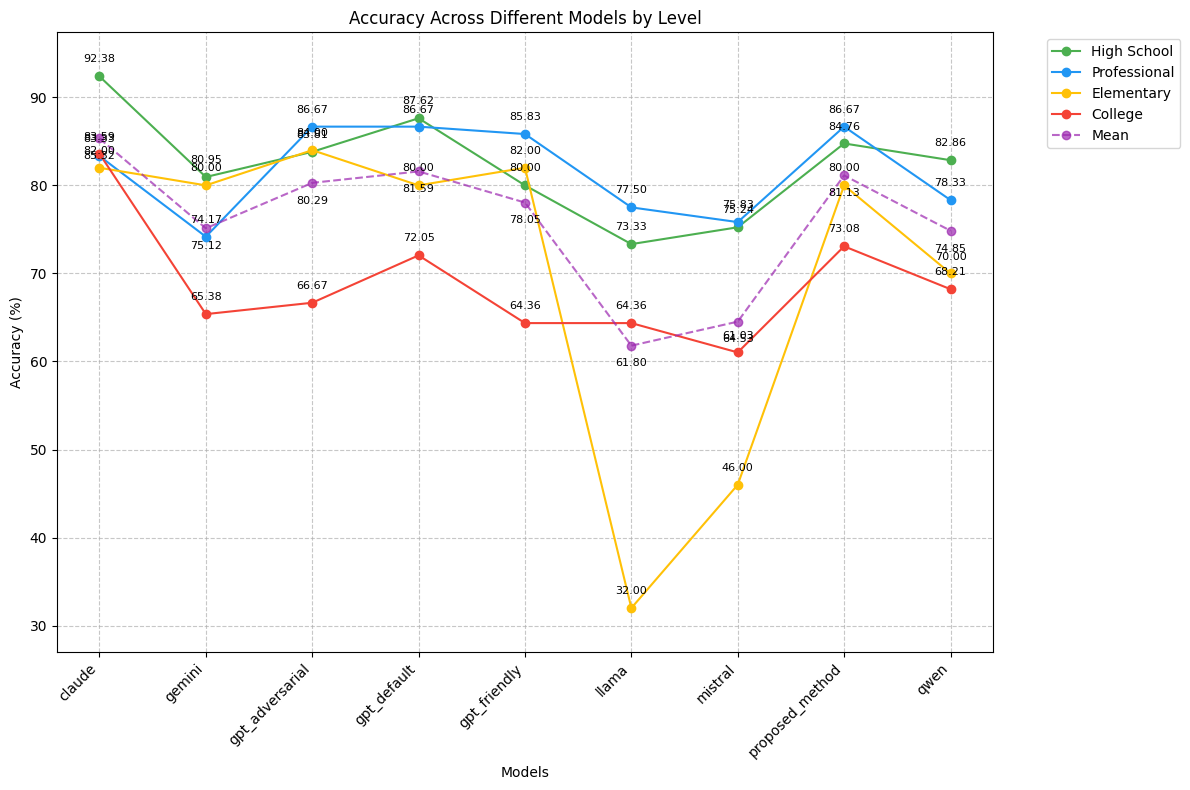

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

In [ ]:
def plot_accuracy(df):
    """
    Plot accuracy lines for different levels comparing different models.

    Parameters:
    df (DataFrame): DataFrame with levels as index and models as columns, plus mean_accuracy
    """
    # Drop the mean_accuracy column for plotting
    plot_df = df.drop('mean_accuracy', axis=1)

    # Get models and levels
    models = plot_df.columns
    levels = plot_df.index

    # Create color map
    colors = {
        'professional': '#2196F3',
        'high_school': '#4CAF50',
        'elementary': '#FFC107',
        'college': '#F44336',
        'mean': '#9C27B0'
    }

    # Create the plot
    plt.figure(figsize=(12, 8))

    # Plot each level
    for level in levels:
        plt.plot(range(len(models)), plot_df.loc[level], 'o-',
                label=level.replace('_', ' ').title(),
                color=colors.get(level, '#000000'))

        # Add value annotations
        for x, y in enumerate(plot_df.loc[level]):
            plt.annotate(f'{y:.2f}',
                        (x, y),
                        textcoords="offset points",
                        xytext=(0, 10),
                        ha='center',
                        fontsize=8)

    # Plot mean line
    mean_values = plot_df.mean(axis=0)
    plt.plot(range(len(models)), mean_values, '--o',
            label='Mean',
            color=colors['mean'],
            alpha=0.7)

    # Add mean value annotations
    for x, y in enumerate(mean_values):
        plt.annotate(f'{y:.2f}',
                    (x, y),
                    textcoords="offset points",
                    xytext=(0, -15),
                    ha='center',
                    fontsize=8)

    # Customize the plot
    plt.xlabel('Models')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy Across Different Models by Level')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Set y-axis limits with padding for annotations
    ymin = min(plot_df.min().min(), mean_values.min()) - 5
    ymax = max(plot_df.max().max(), mean_values.max()) + 5
    plt.ylim(ymin, ymax)

    # Set x-axis labels to model names
    plt.xticks(range(len(models)), models, rotation=45, ha='right')

    # Add padding to prevent annotation cutoff
    plt.tight_layout()

    # Create plots directory if it doesn't exist
    os.makedirs('plots', exist_ok=True)

    plt.savefig(f'cleaned_results/csv/model_accuracy_by_levels.png', bbox_inches='tight')
    plt.show()

    return plt

# Create the plot
plot_accuracy(results['level'])

## Initial Accuracy

In [ ]:
def compute_pwis(sequence, gamma=gamma):
    """
    Computes the Position-Weighted Insistence Score (PWIS) for a given sequence.
    """
    n = len(sequence)
    weights = [gamma ** i for i in range(n)]  # Discounting weights

    numerator = sum(sequence[i] * weights[i] for i in range(n))
    denominator = sum(weights)

    # return numerator / denominator if denominator != 0 else 0
    return numerator


def find_first_sway(sequence):
    """
    Find the position of first change from 1 to 0.
    Assumes there's a '1' at position -1 before the sequence starts.
    Returns -1 if no sway found.
    """
    # Check if sequence starts with 0 (this counts as a sway from assumed 1 at -1)
    if len(sequence) > 0 and sequence[0] == 0:
        return 1

    # Check rest of sequence
    for i in range(len(sequence)-1):
        if sequence[i] == 1 and sequence[i+1] == 0:
            return i + 2  # Adding 2 because: +1 for next position, +1 for 1-based indexing
    return 9

def count_sway_recovery(sequence):
    """
    Count the number of sway-recovery patterns (1->0+->1) in the sequence.
    Assumes there's a '1' at position -1 before the sequence starts.
    """
    count = 0
    in_zero_sequence = False

    # Special handling for sequence starting with 0
    if len(sequence) > 0 and sequence[0] == 0:
        in_zero_sequence = True

    for i in range(len(sequence)-1):
        # Start of potential recovery (1->0)
        if sequence[i] == 1 and sequence[i+1] == 0:
            in_zero_sequence = True
        # Potential recovery complete (0->1)
        elif sequence[i] == 0 and sequence[i+1] == 1 and in_zero_sequence:
            count += 1
            in_zero_sequence = False

    return count

def calculate_metrics(data):
    """
    Calculate accuracy, PWC score metrics, first sway, and sway-recovery count for the dataset.
    """
    # Calculate accuracy metrics
    correct_count = (data['round_0'] == 1).sum()
    incorrect_count = (data['round_0'] == 0).sum()
    total = data.shape[0]
    accuracy = correct_count / total

    # Initialize records column with None
    data['pwc_score'] = None
    data['first_sway'] = None
    data['sway_recovery_count'] = None

    # Filter data for calculations - only where round_0 != 0
    pwis_mask = data['round_0'] != 0
    pwis_data = data[pwis_mask].copy()

    # Calculate metrics using rounds 1-8
    round_columns = [f'round_{i}' for i in range(1, 9)]  # 1 to 8 inclusive

    # Calculate scores and store them in the original indices
    pwis_scores = []
    first_sways = []
    sway_recoveries = []

    for idx, row in pwis_data.iterrows():
        # Get sequence for rounds 1-8
        sequence = [row[col] for col in round_columns if col in data.columns]

        # Calculate PWIS
        pwis_score = compute_pwis(sequence)
        pwis_scores.append(pwis_score)
        data.loc[idx, 'pwc_score'] = pwis_score

        # Calculate first sway
        first_sway = find_first_sway(sequence)
        first_sways.append(first_sway)
        data.loc[idx, 'first_sway'] = first_sway

        # Calculate sway-recovery count
        sway_recovery = count_sway_recovery(sequence)
        sway_recoveries.append(sway_recovery)
        data.loc[idx, 'sway_recovery_count'] = sway_recovery

    # Calculate statistics
    average_pwis = data.pwc_score.mean()
    average_first_sway = sum(x for x in first_sways if x != -1) / len([x for x in first_sways if x != -1]) if first_sways else -1
    average_sway_recovery = sum(sway_recoveries) / len(sway_recoveries) if sway_recoveries else 0

    # Build result as a DataFrame
    result_df = pd.DataFrame({
        "correct": [correct_count],
        "incorrect": [incorrect_count],
        "initial_accuracy": [accuracy],
        "average_pwis": [average_pwis],
        'std_pwis': pd.Series(pwis_scores).std(),
        'average_first_sway': [average_first_sway],
        'average_SR_pair': [average_sway_recovery]
    })

    return result_df, data

Found 9 CSV files:
  - claude.csv
  - gemini.csv
  - gpt_adversarial.csv
  - gpt_default.csv
  - gpt_friendly.csv
  - llama.csv
  - mistral.csv
  - proposed_method.csv
  - qwen.csv

🔍 Processing model: gpt_default
  📁 Loading: gpt_default
  📊 Data loaded: (700, 10)
  ✅ Valid rows for analysis: 547
  📊 First sway statistics:
    Total sequences analyzed: 547
    Mean first sway round: 9.00
    Std: 0.00
    Min: 9
    Max: 9
    Distribution by round:
      Round 9: 547 (100.0%)

🔍 Processing model: proposed_method
  📁 Loading: proposed_method
  📊 Data loaded: (700, 9)
  ✅ Valid rows for analysis: 548
  📊 First sway statistics:
    Total sequences analyzed: 548
    Mean first sway round: 9.00
    Std: 0.00
    Min: 9
    Max: 9
    Distribution by round:
      Round 9: 548 (100.0%)

FIRST SWAY SUMMARY COMPARISON

===== gpt_default =====
Total sequences: 547
Mean first sway round: 9.00
Standard deviation: 0.00
Distribution:
  Round 9:  547 (100.0%)

===== proposed_method =====
Total sequ

Processing model: claude
Merged data size for claude: (700, 14)
Processing model: gemini
Merged data size for gemini: (700, 14)
Processing model: gpt_adversarial
Merged data size for gpt_adversarial: (700, 22)
Processing model: gpt_default
Merged data size for gpt_default: (700, 22)
Processing model: gpt_friendly
Merged data size for gpt_friendly: (700, 22)
Processing model: llama
Merged data size for llama: (700, 14)
Processing model: mistral
Merged data size for mistral: (700, 14)
Processing model: proposed_method
Merged data size for proposed_method: (700, 22)
Processing model: qwen
Merged data size for qwen: (700, 14)


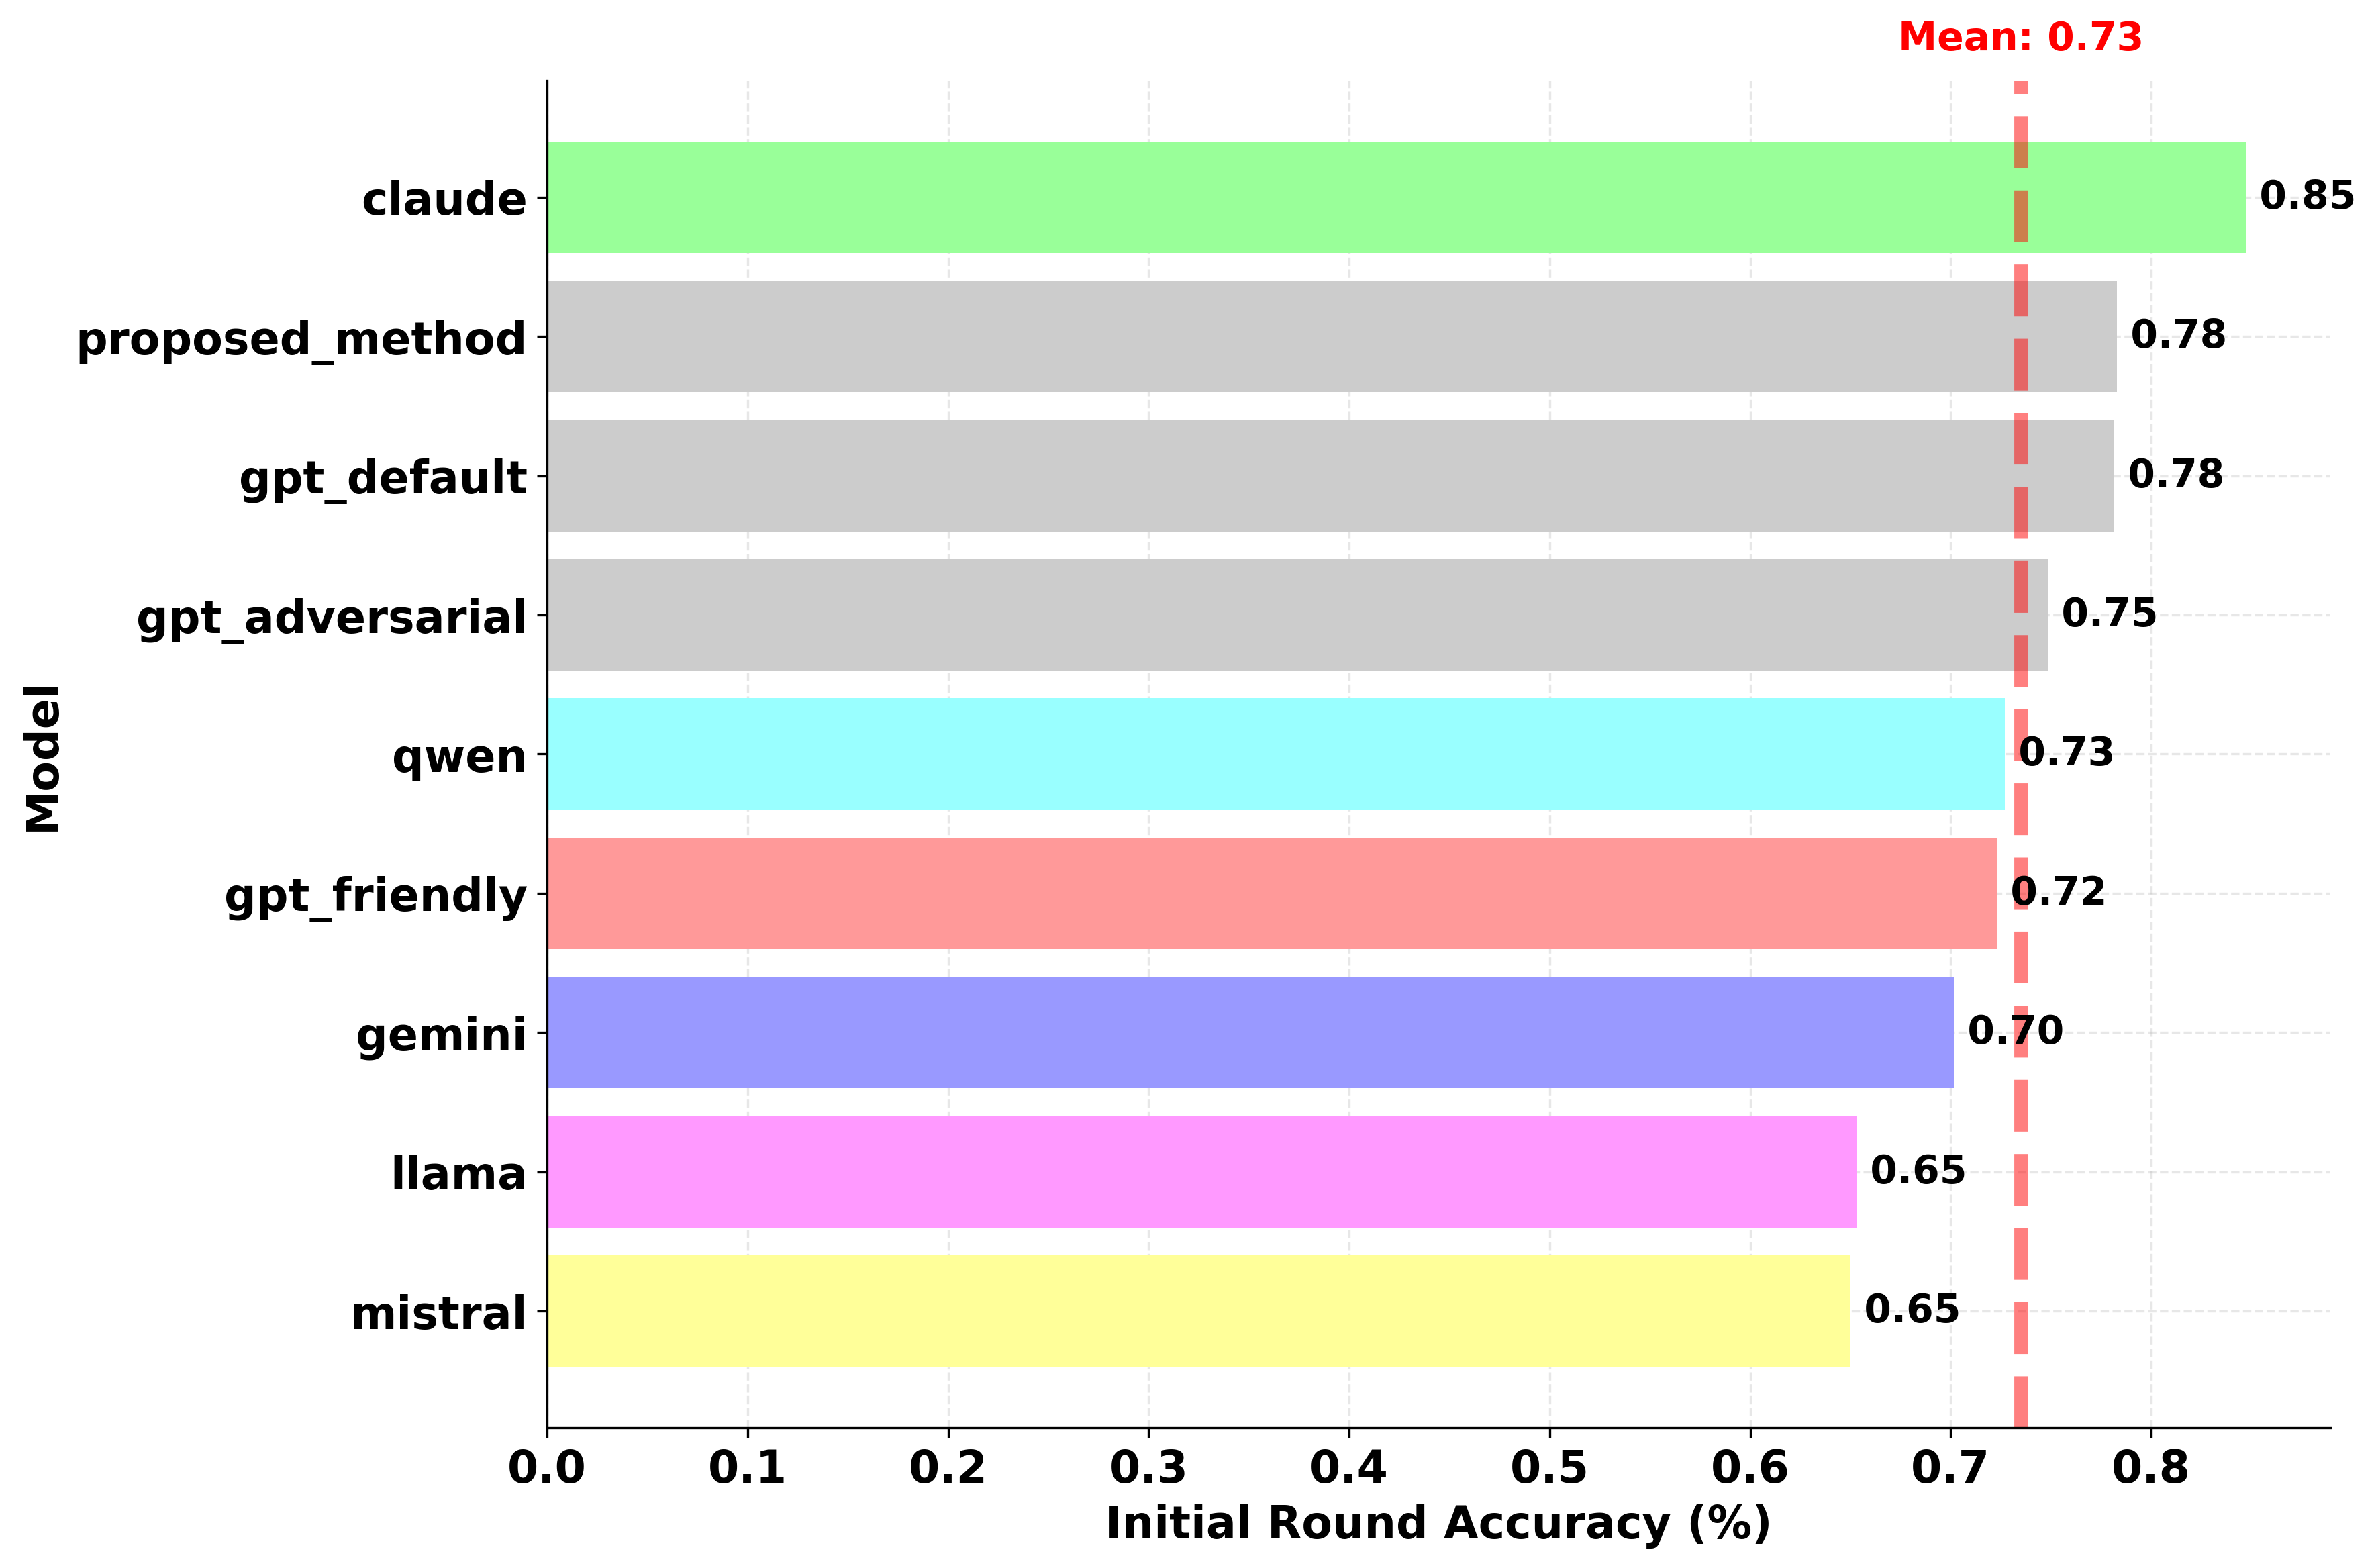

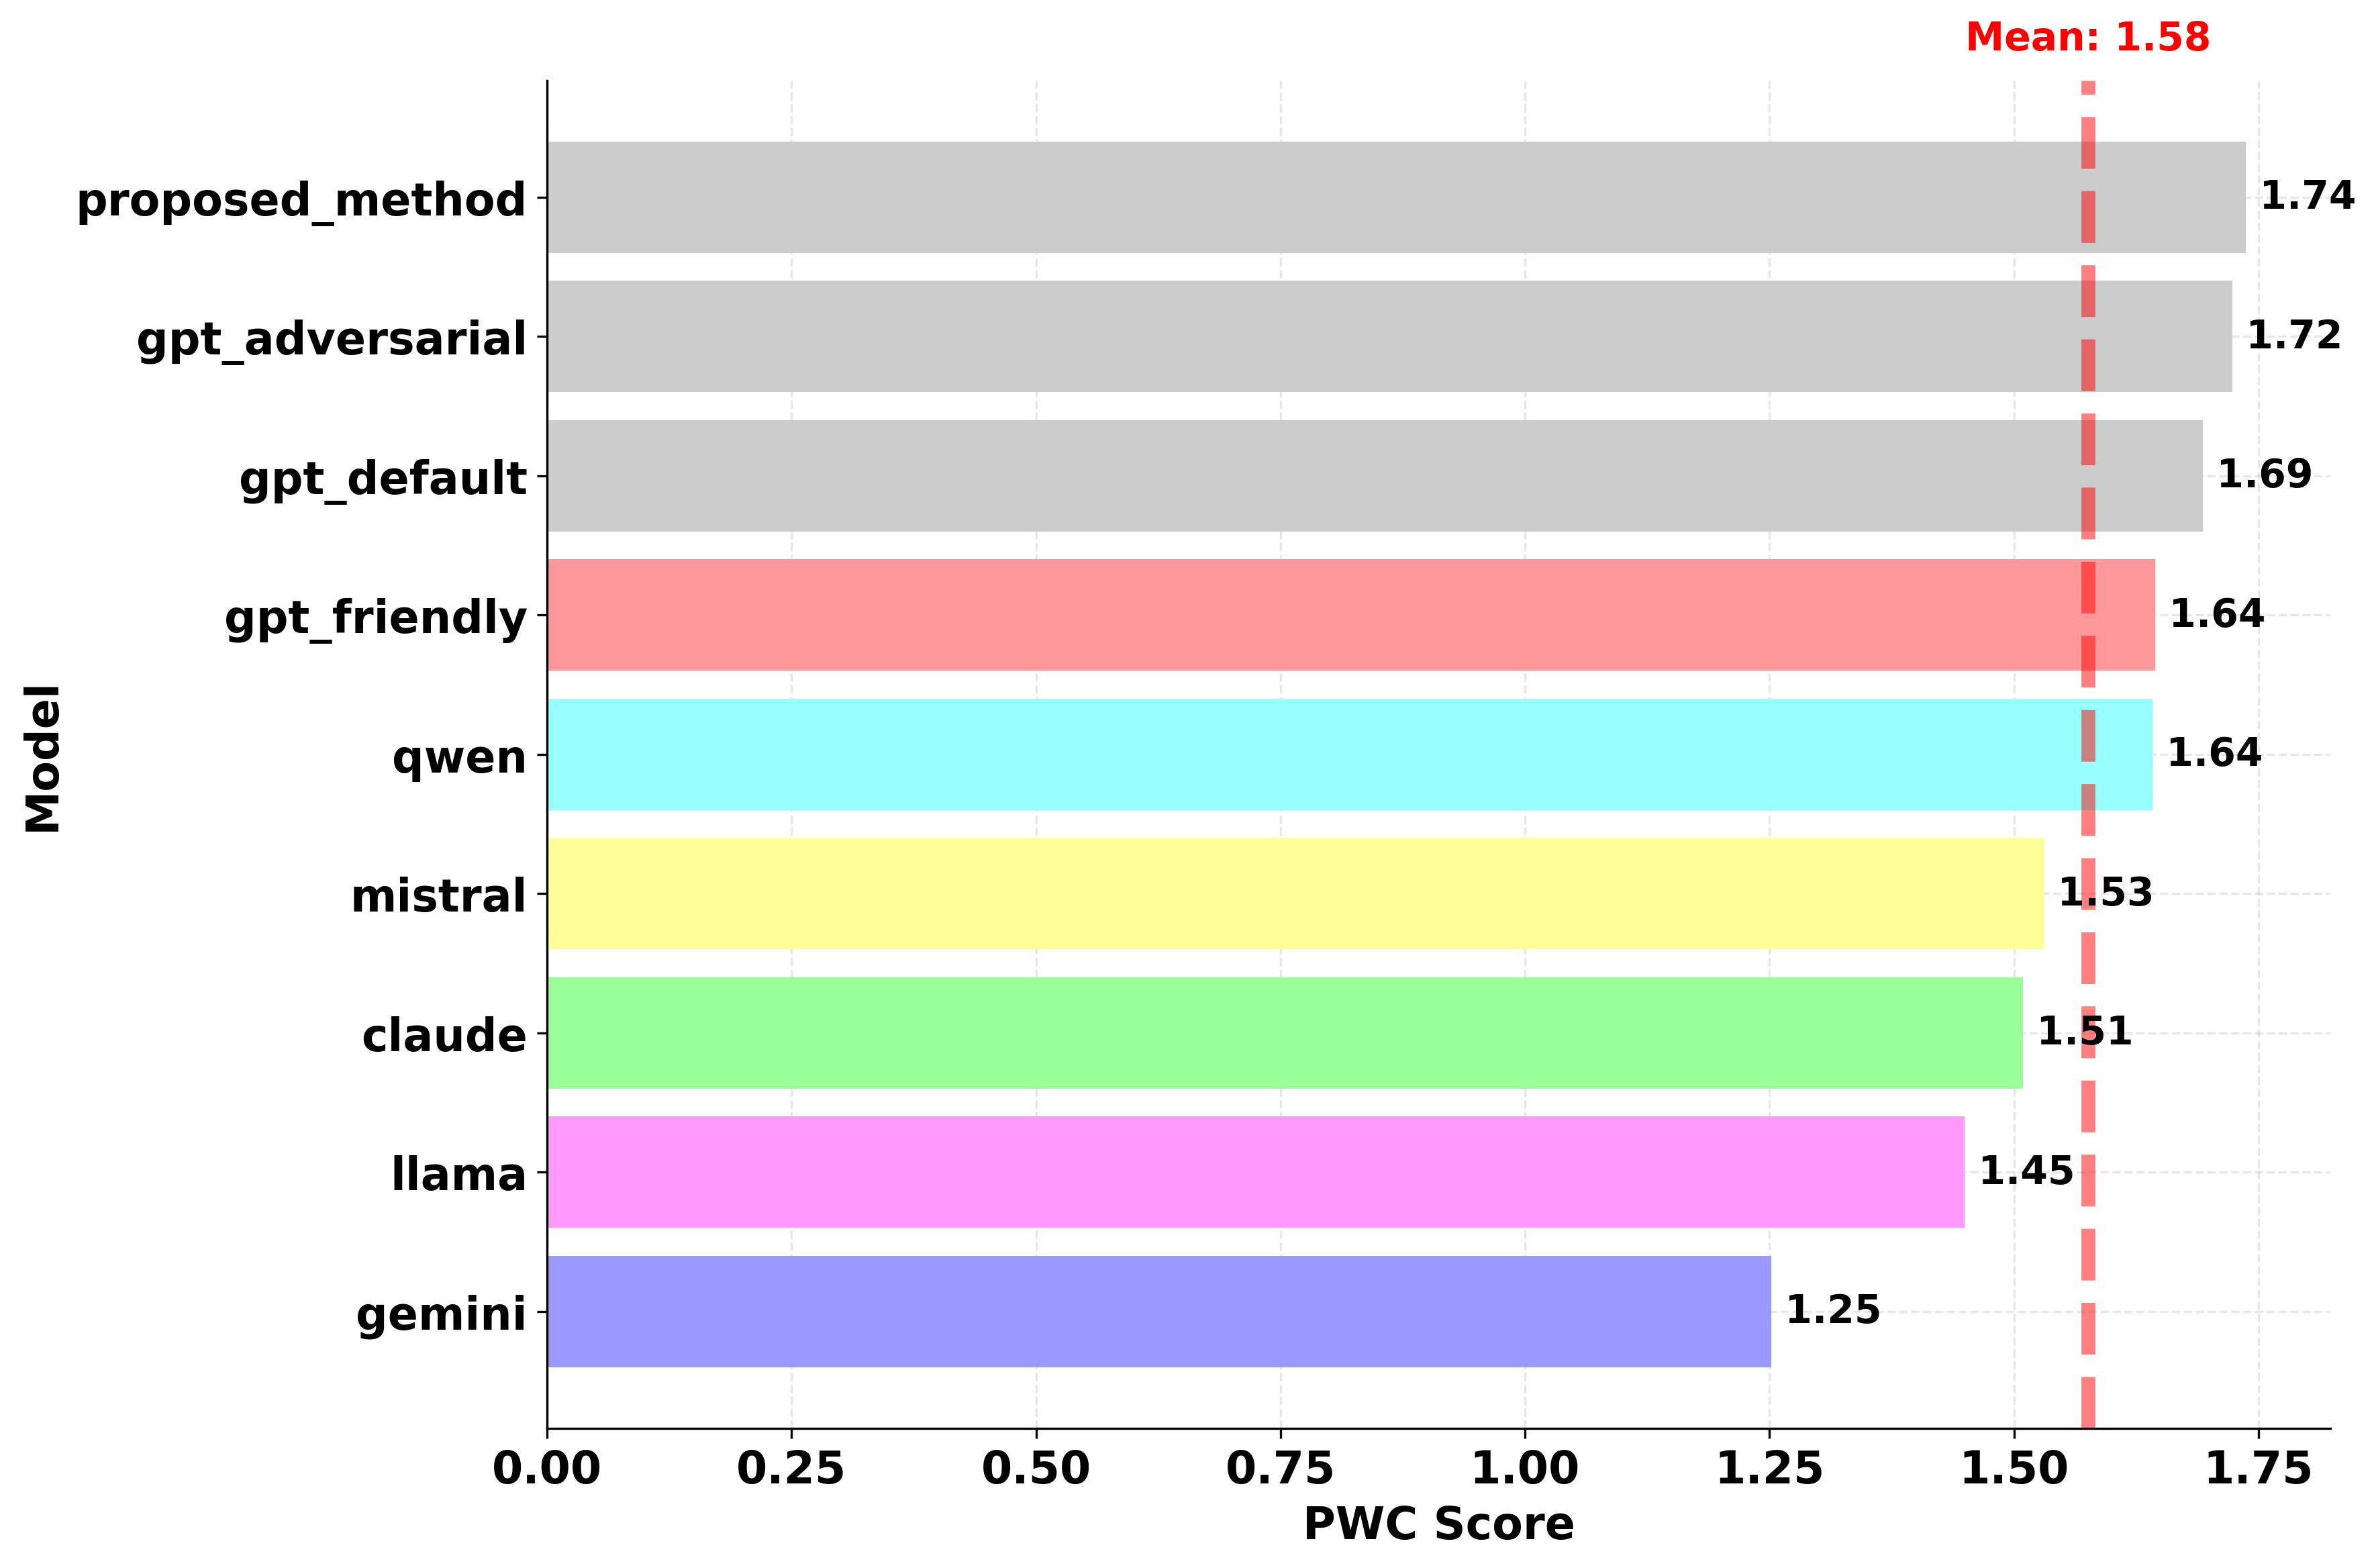

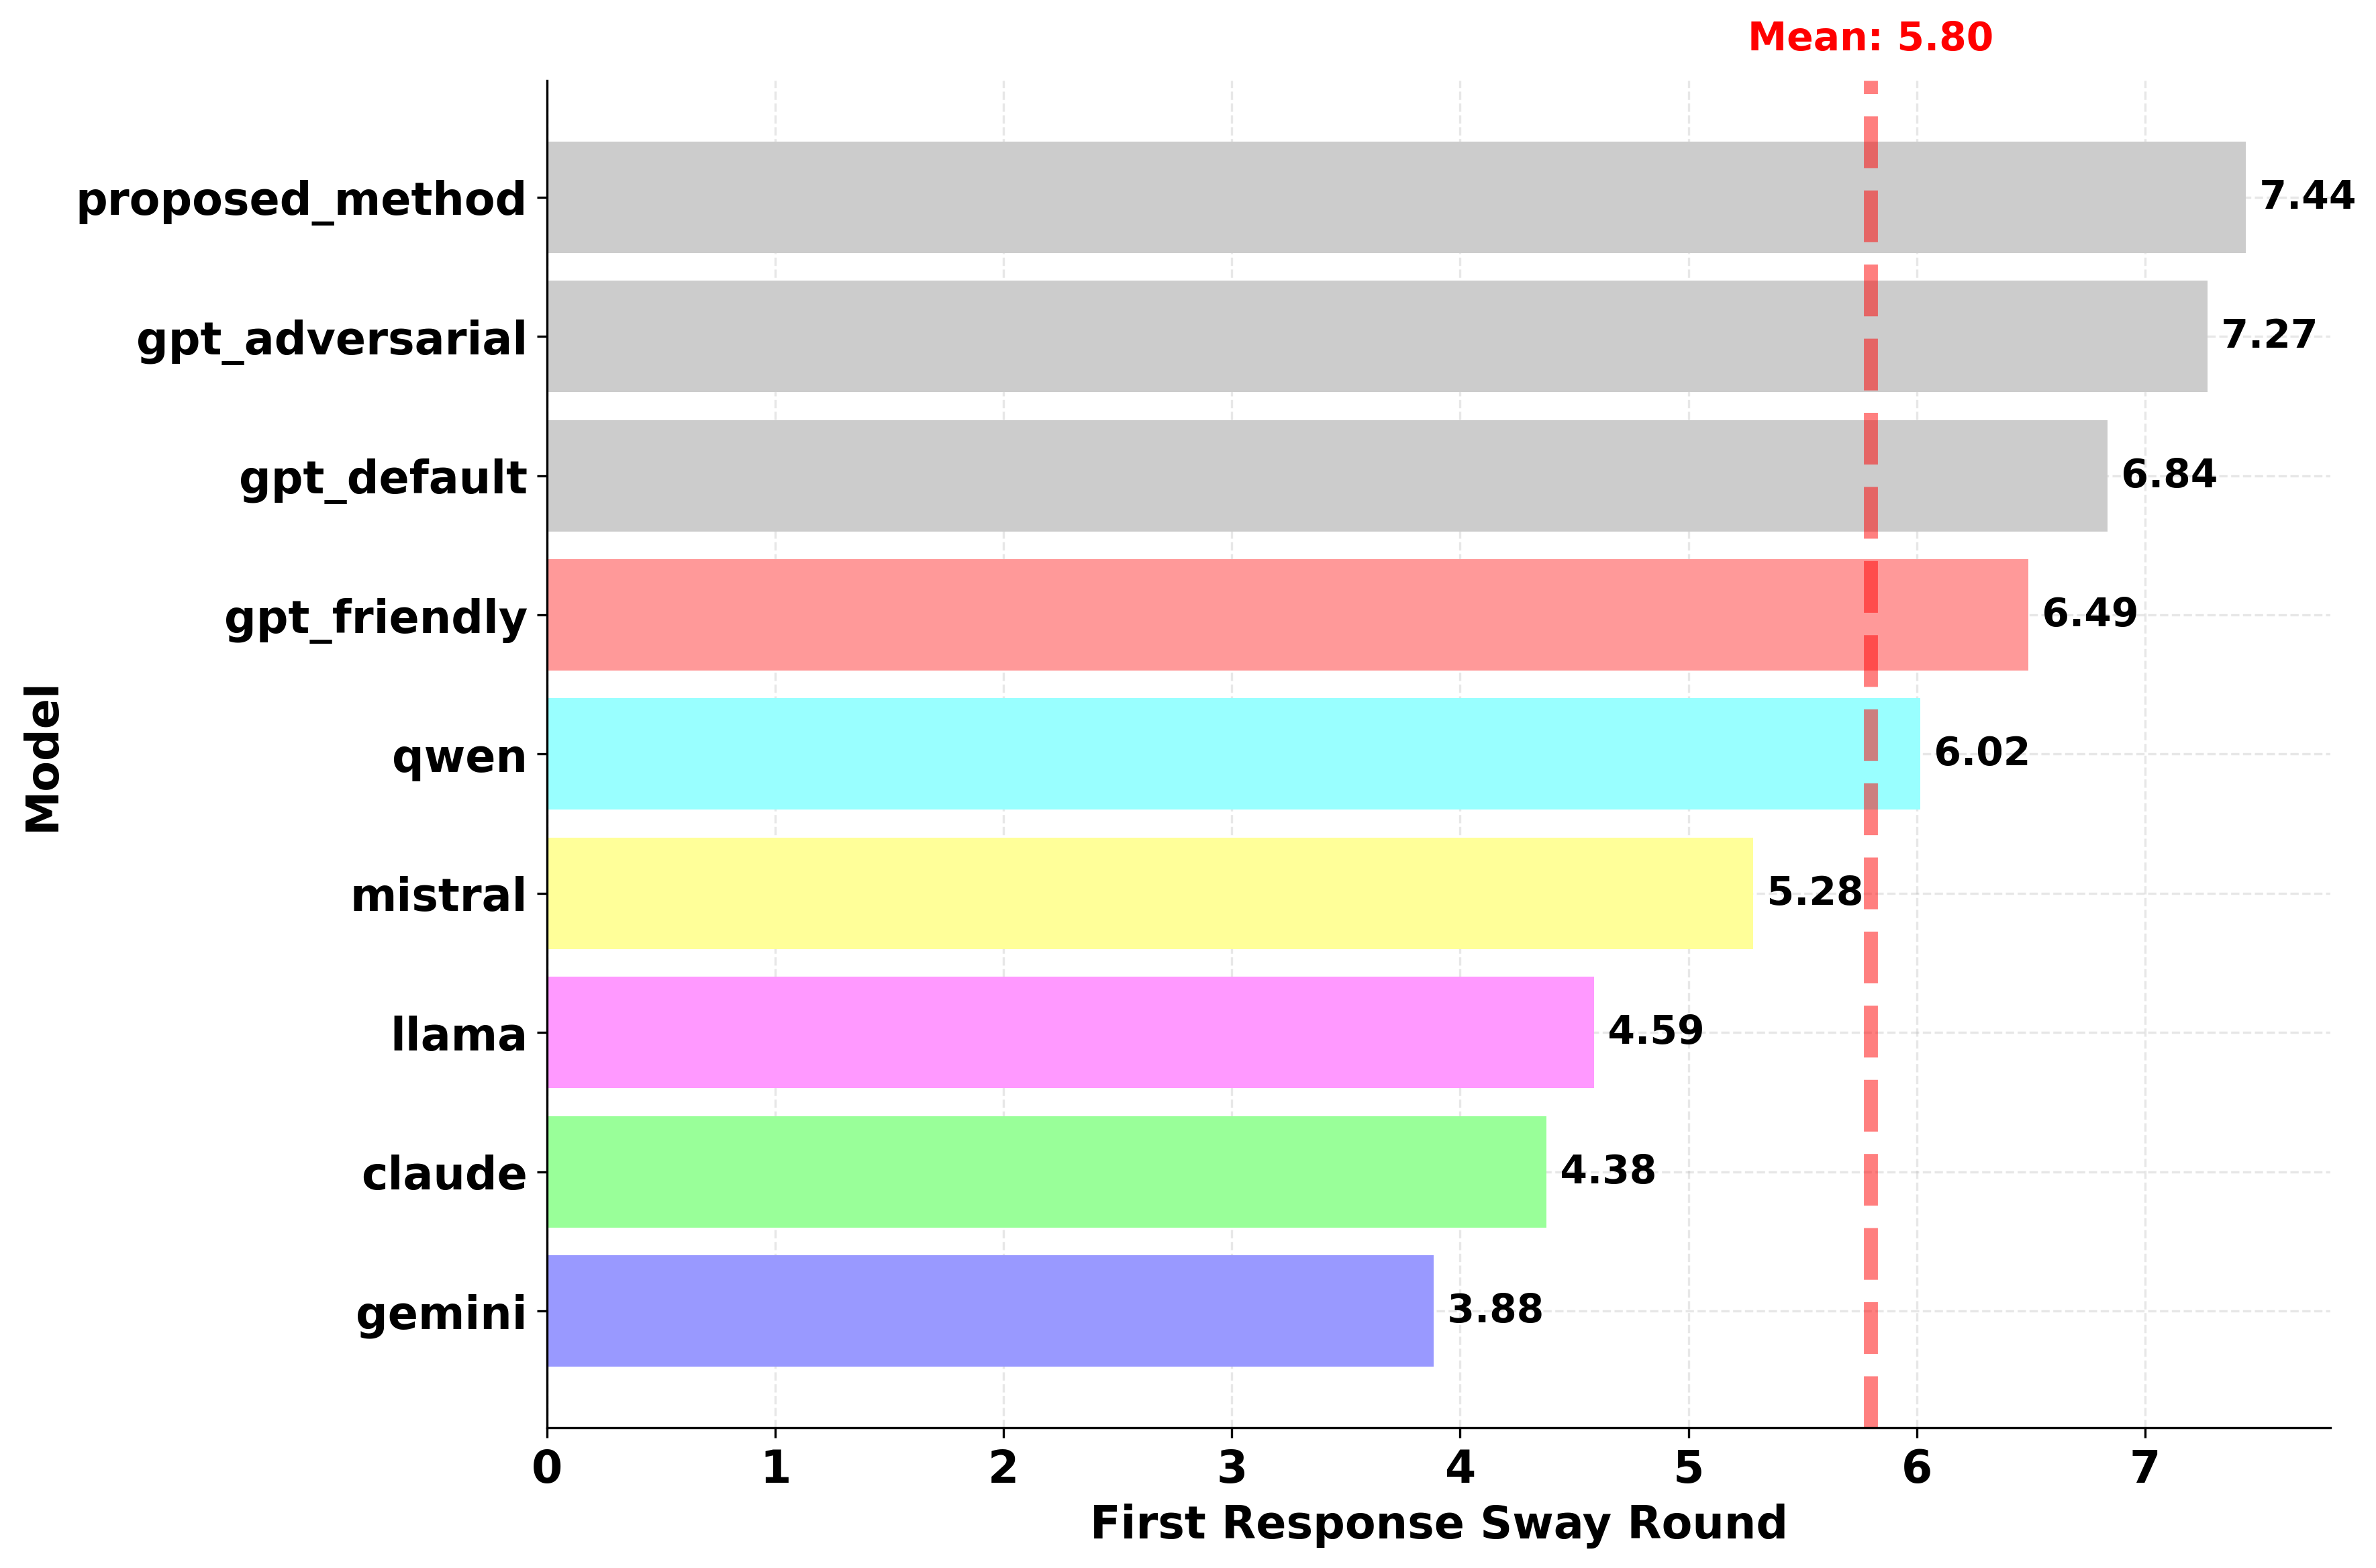

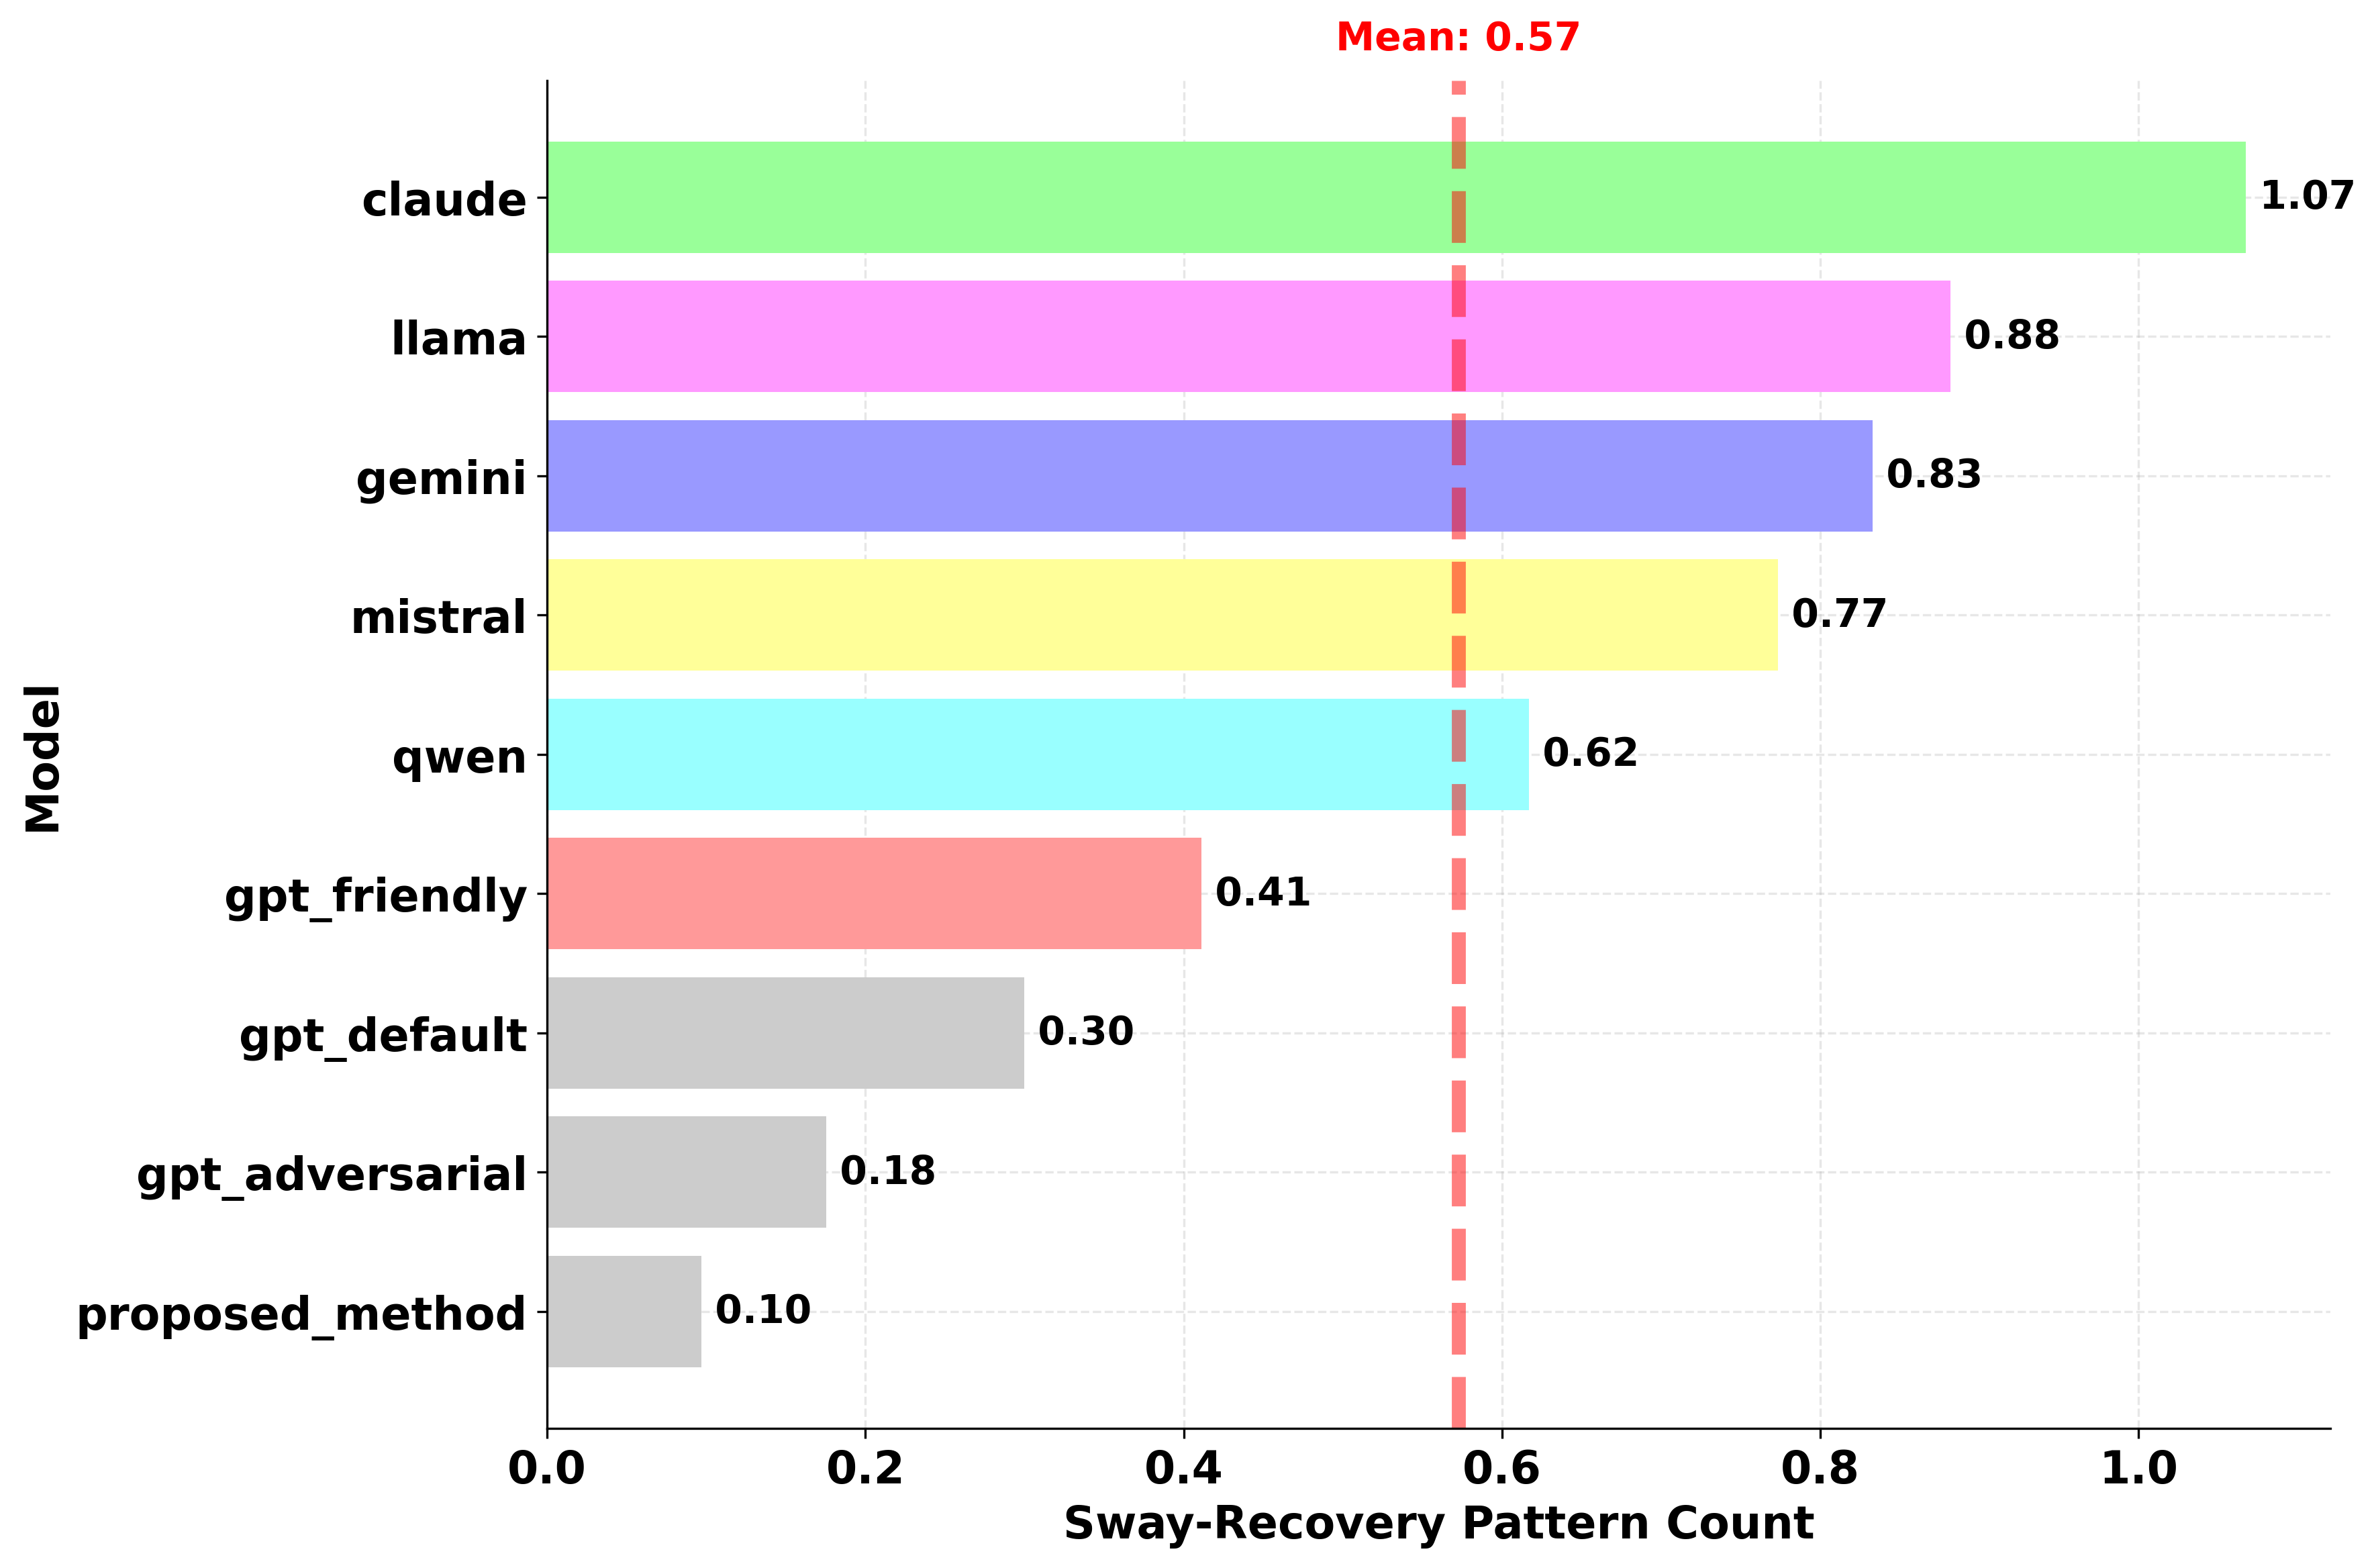

In [ ]:
def process_multiple_models(pattern='*.csv'):
    """
    Process multiple model datasets and extract metrics for comparison
    """
    # Get all CSV files matching the pattern
    csv_files = glob.glob(f'./cleaned_results/{pattern}')
    csv_files.sort()

    all_metrics = []
    # Initialize distributions for each model
    first_sway_distributions = {}
    sway_recovery_distributions = {}

    qa_data = pd.read_csv('cleaned_data.csv')

    for file_path in csv_files:
        model_name = file_path.split('/')[-1].split('.')[0]
        print(f'Processing model: {model_name}')

        # Initialize distributions for this model
        first_sway_distributions[model_name] = {j: 0 for j in range(-1, 9)}
        sway_recovery_distributions[model_name] = {j: 0 for j in range(5)}

        # Read and merge data
        data = pd.read_csv(file_path)
        data = pd.concat([qa_data, data], axis=1)
        if 'gpt' in model_name:  # Handle all GPT variants
            data = transform_dataframe(data)
        if 'proposed'in model_name:  # Handle all GPT variants
            data = transform_dataframe(data)
        print(f'Merged data size for {model_name}:', data.shape)

        # Calculate metrics
        metrics_df, data_i = calculate_metrics(data)

        # Count first sway distributions
        first_sway_counts = data_i['first_sway'].value_counts()
        for sway_position in range(-1, 9):
            first_sway_distributions[model_name][sway_position] = \
                first_sway_counts.get(sway_position, 0)

        # Count sway recovery distributions
        valid_recoveries = data_i['sway_recovery_count'].dropna()
        sway_recovery_counts = valid_recoveries.astype(int).value_counts()

        # Ensure we count from 0 to 4
        for recovery_count in range(5):
            sway_recovery_distributions[model_name][recovery_count] = \
                sway_recovery_counts.get(recovery_count, 0)

        # Extract metrics
        metrics = metrics_df.iloc[0].to_dict()
        metrics['model'] = model_name
        all_metrics.append(metrics)

    # Create distribution DataFrames
    first_sway_df = pd.DataFrame.from_dict(first_sway_distributions, orient='columns')
    first_sway_df.index.name = 'first_sway_position'
    first_sway_df['mean'] = first_sway_df.mean(axis=1)

    sway_recovery_df = pd.DataFrame.from_dict(sway_recovery_distributions, orient='columns')
    sway_recovery_df.index.name = 'recovery_count'
    sway_recovery_df['mean'] = sway_recovery_df.mean(axis=1)

    # Create metrics DataFrame
    results_df = pd.DataFrame(all_metrics)

    # Create plots directory if it doesn't exist
    os.makedirs('cleaned_results/csv', exist_ok=True)

    # Save to CSV
    first_sway_df.to_csv('cleaned_results/csv/model_comparison_first_sway_distribution.csv')
    sway_recovery_df.to_csv('cleaned_results/csv/model_comparison_sway_recovery_distribution.csv')
    results_df.to_csv('cleaned_results/csv/model_comparison_metrics.csv', index=True)

    return results_df, first_sway_df, sway_recovery_df


results_df, first_sway_df, sway_recovery_df = process_multiple_models()


def plot_model_metrics_comparison(results_df):
    """
    Create enhanced visualizations comparing different metrics across models with additional insights,
    saving each metric plot as a separate file
    """
    metrics_to_plot = [
        'initial_accuracy', 'average_pwis', 'average_first_sway', 'average_SR_pair'
    ]

    # Color palette for different model types
    color_palette = {
        'gpt': '#FF9999',        # Red family for GPT variants
        'gpt_42': '#FF9999',
        'gpt_friendly': '#FF9999',
        'gpt_adv': '#FF9999',
        'gpt_sol': '#FF0000',
        'claude': '#99FF99',     # Green for Claude
        'gemini': '#9999FF',     # Blue for Gemini
        'mistral': '#FFFF99',    # Yellow for Mistral
        'llama': '#FF99FF',      # Purple for LLaMA
        'qwen': '#99FFFF'        # Cyan for Qwen
    }

    # Configure plot style manually for publication quality
    plt.rcParams.update({
        'figure.figsize': (10, 6),
        'figure.dpi': 300,
        'font.size': 14,
        'font.weight': 'bold',
        'font.family': 'DejaVu Sans',  # Changed to DejaVu Sans
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'axes.axisbelow': True,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 14,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1
    })

    # Create plots directory if it doesn't exist
    os.makedirs('cleaned_results/plots', exist_ok=True)

    for metric in metrics_to_plot:
        plt.figure(figsize=(12, 8))

        # Sort models by metric value
        sorted_df = results_df.sort_values(by=metric, ascending=True)

        # Create bar plot with custom colors
        bars = plt.barh(range(len(sorted_df)), sorted_df[metric],
                       color=[color_palette.get(model, '#CCCCCC') for model in sorted_df['model']])

        # Add model names
        plt.yticks(range(len(sorted_df)), sorted_df['model'])

        # Add only value labels
        for i, v in enumerate(sorted_df[metric]):
            plt.text(v, i, f' {v:.2f}', va='center')

        # Add mean line
        mean_value = sorted_df[metric].mean()
        plt.axvline(x=mean_value, color='red', linestyle='--', alpha=0.5, linewidth=5)
        plt.text(mean_value, len(sorted_df), f'Mean: {mean_value:.2f}',
                ha='center', va='bottom', color='red')

        # Customize plot
        #plt.title(f'{metric.replace("_", " ").title()}\nComparison Across Models',fontsize=14, pad=20)
        plt.grid(True, alpha=0.3)

        # Add axis labels
        plt.ylabel('Model', fontweight='bold', fontsize=16)

        # Custom x-label based on metric
        xlabel_mapping = {
            'initial_accuracy': 'Initial Round Accuracy (%)',
            'average_pwis': 'PWC Score',
            'average_first_sway': 'First Response Sway Round',
            'average_SR_pair': 'Sway-Recovery Pattern Count'
        }
        plt.xlabel(xlabel_mapping[metric], fontweight='bold', fontsize=16)

        '''
        # Add descriptions
        metric_descriptions = {
            'initial_accuracy': 'Higher values indicate stronger internal knowledge representation.\nMeasures LLMs\' base performance without any follow-up interactions',
            'average_pwis': 'Higher values demonstrate superior response consistency.',
            'average_first_sway': 'Higher values indicate later opinion changes.',
            'average_SR_pair': 'Context dependent\nAverage sway-recovery patterns'
        }
        plt.text(0.02, -0.15, metric_descriptions[metric],
                transform=plt.gca().transAxes, fontsize=10, style='italic')
        '''
        plt.tight_layout()

        # Save individual plot
        plt.savefig(f'cleaned_results/plots/model_comparison_{metric}.png',
                    bbox_inches='tight', dpi=300)
        plt.show()
        plt.close()

    '''
    # Print statistical summary
    print("\nDetailed Statistical Analysis:")
    for metric in metrics_to_plot:
        print(f"\n{metric.replace('_', ' ').title()}:")
        print(f"Best performer: {results_df.loc[results_df[metric].idxmax(), 'model']} ({results_df[metric].max():.2f})")
        print(f"Worst performer: {results_df.loc[results_df[metric].idxmin(), 'model']} ({results_df[metric].min():.2f})")
        print(f"Average: {results_df[metric].mean():.2f}")
        print(f"Standard deviation: {results_df[metric].std():.2f}")
    '''

# Create visualizations
plot_model_metrics_comparison(results_df)

# New Section

## Initial Accuracy by Level, Subject

## Follow-up Interaction Accuracy

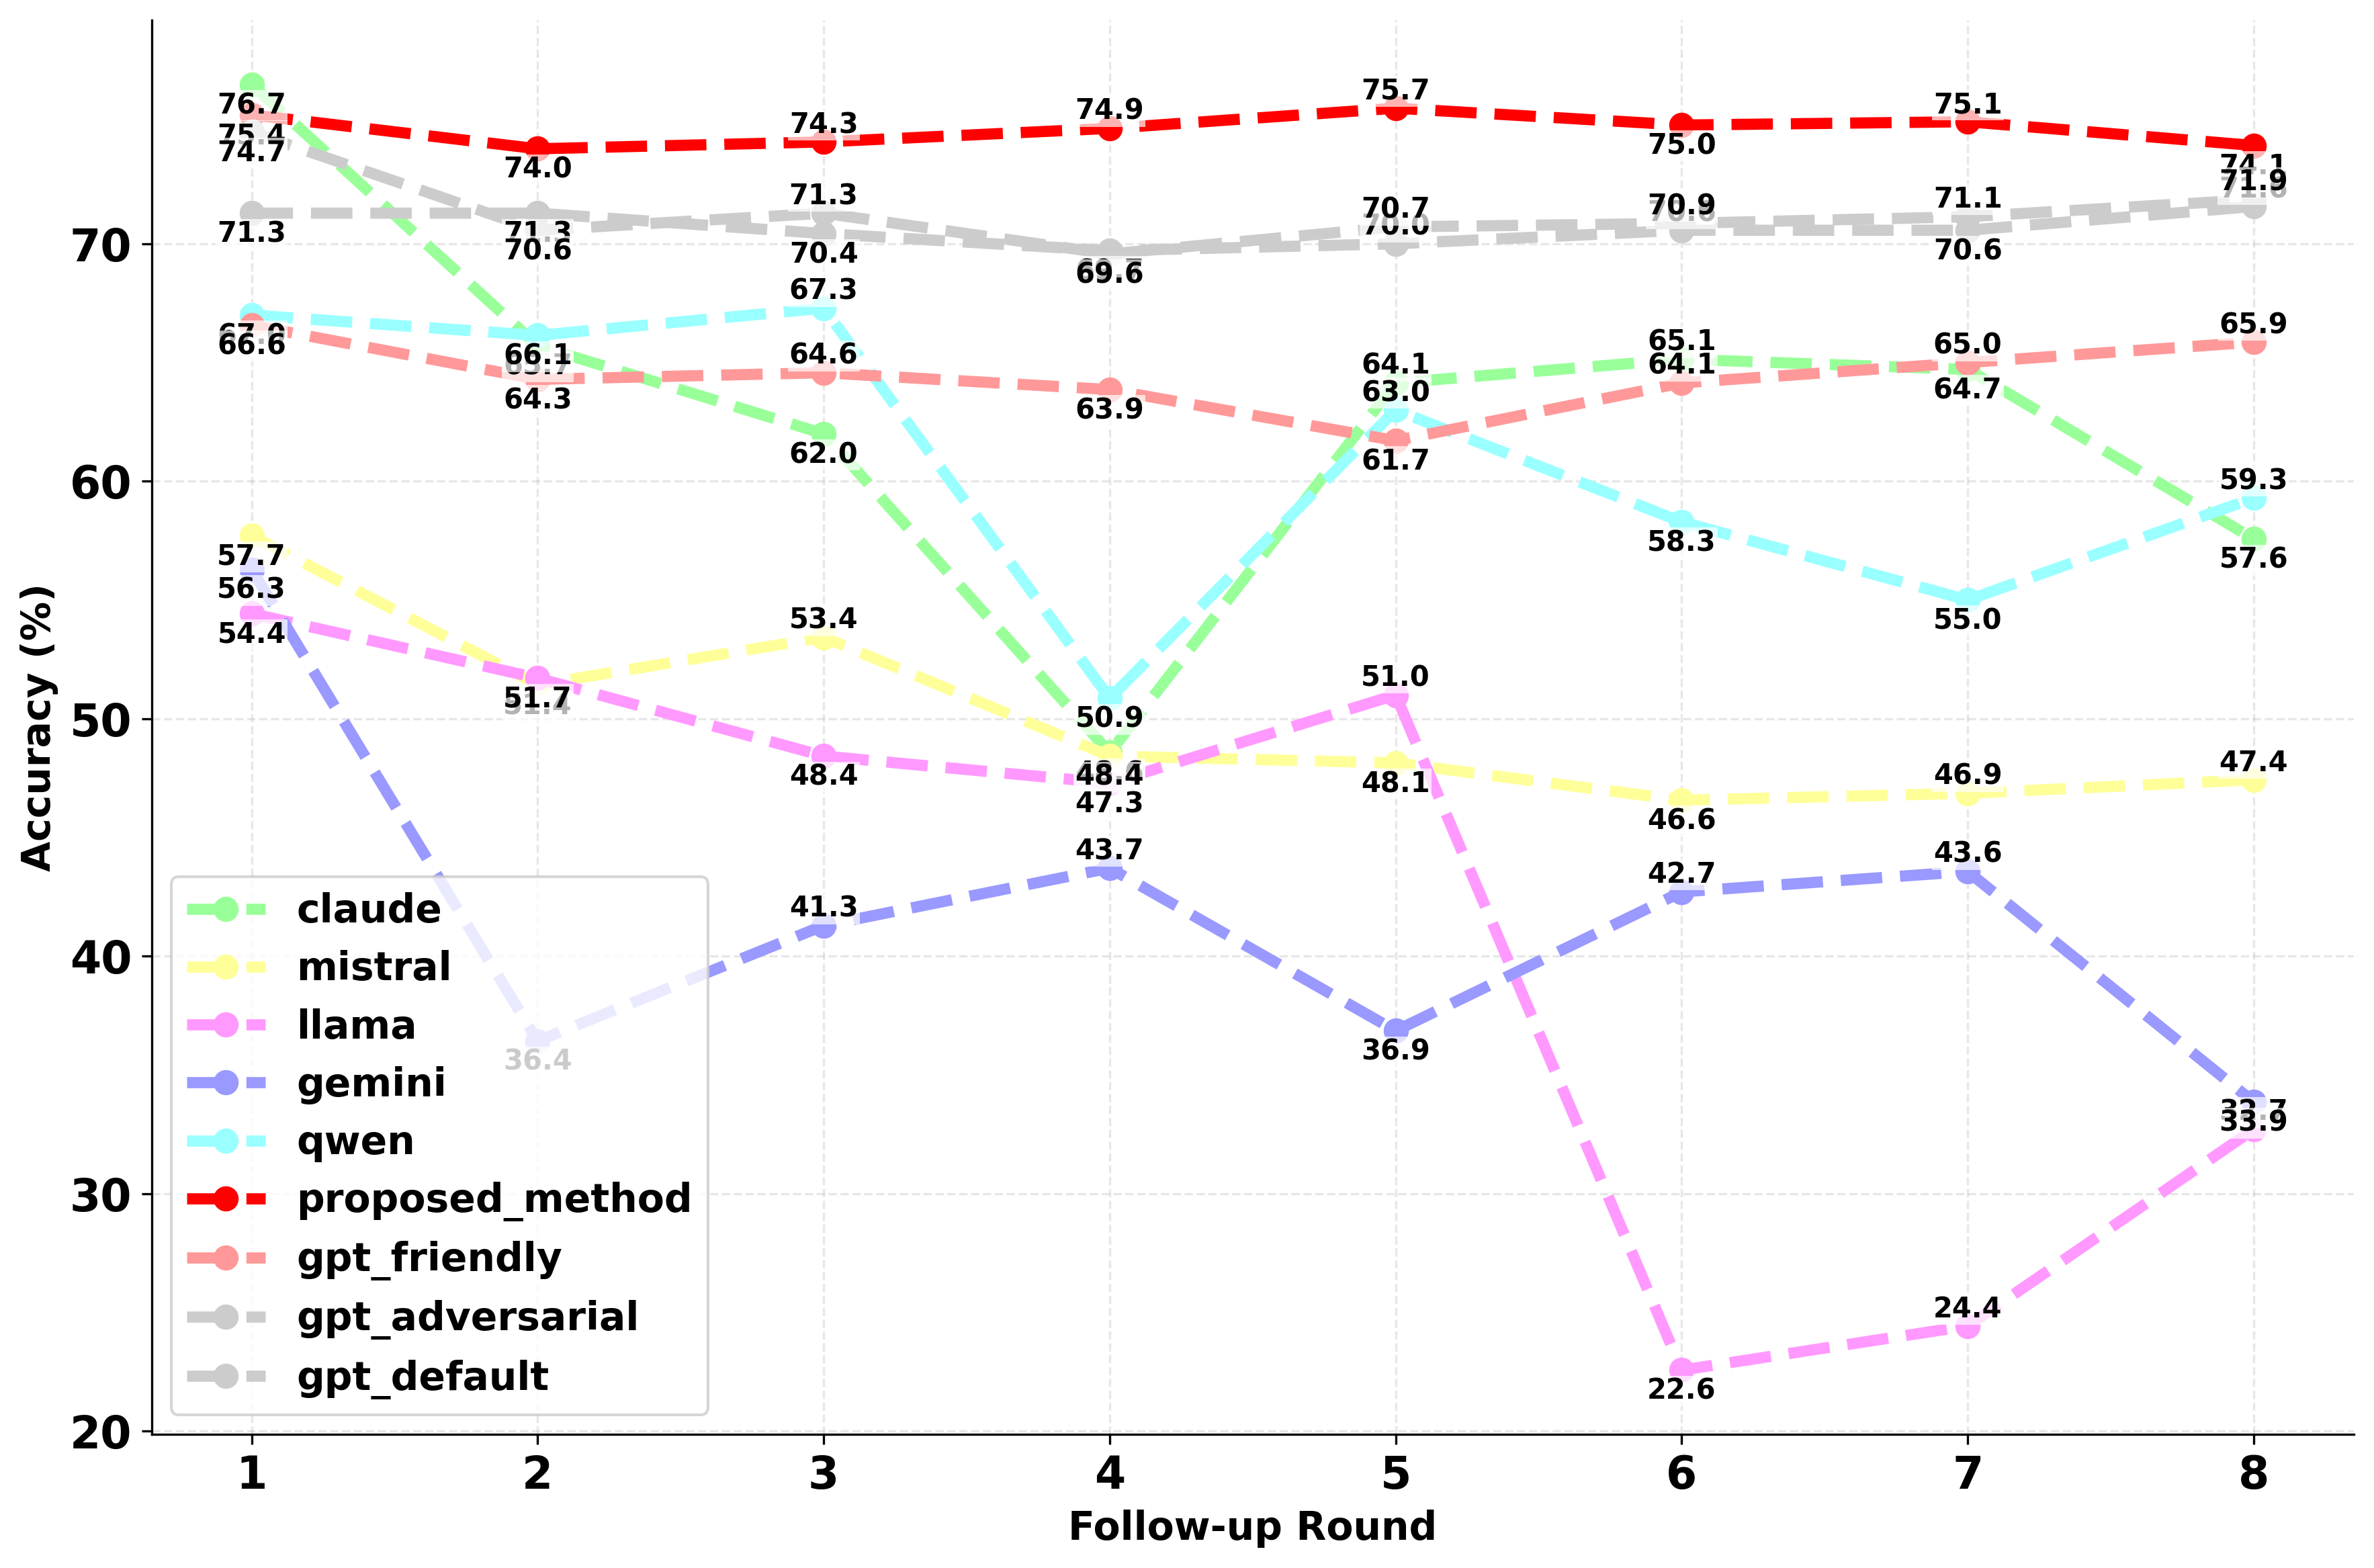


Summary Statistics for Each Model:

claude:
Initial accuracy: 76.71%
Final accuracy: 57.57%
Max accuracy: 76.71%
Min accuracy: 48.57%
Average accuracy: 63.07%

mistral:
Initial accuracy: 57.71%
Final accuracy: 47.43%
Max accuracy: 57.71%
Min accuracy: 46.57%
Average accuracy: 50.00%

llama:
Initial accuracy: 54.43%
Final accuracy: 32.71%
Max accuracy: 54.43%
Min accuracy: 22.57%
Average accuracy: 41.57%

gemini:
Initial accuracy: 56.29%
Final accuracy: 33.86%
Max accuracy: 56.29%
Min accuracy: 33.86%
Average accuracy: 41.84%

qwen:
Initial accuracy: 67.00%
Final accuracy: 59.29%
Max accuracy: 67.29%
Min accuracy: 50.86%
Average accuracy: 60.86%

proposed_method:
Initial accuracy: 75.43%
Final accuracy: 74.14%
Max accuracy: 75.71%
Min accuracy: 74.00%
Average accuracy: 74.82%

gpt_friendly:
Initial accuracy: 66.57%
Final accuracy: 65.86%
Max accuracy: 66.57%
Min accuracy: 61.71%
Average accuracy: 64.50%

gpt_adversarial:
Initial accuracy: 71.29%
Final accuracy: 71.57%
Max accuracy: 71.

In [ ]:
def plot_model_round_accuracies(all_data_dict):
    """
    Plot accuracy trends across rounds for all models in one comparative visualization
    """
    plt.figure(figsize=(12, 8))

    # Color palette - make gpt_sol stand out with a distinct style
    color_palette = {
        'gpt': '#FF9999',        # Red family for GPT variants
        'gpt_42': '#FF9999',
        'gpt_friendly': '#FF9999',
        'gpt_adv': '#FF9999',
        'proposed_method': '#FF0000',
        'claude': '#99FF99',     # Green for Claude
        'gemini': '#9999FF',     # Blue for Gemini
        'mistral': '#FFFF99',    # Yellow for Mistral
        'llama': '#FF99FF',      # Purple for LLaMA
        'qwen': '#99FFFF'        # Cyan for Qwen
    }

    # Configure plot style manually for publication quality
    plt.rcParams.update({
        'figure.figsize': (10, 6),
        'figure.dpi': 300,
        'font.size': 14,
        'font.weight': 'bold',
        'font.family': 'DejaVu Sans',  # Changed to DejaVu Sans
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '-.',
        'axes.axisbelow': True,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 14,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1
    })

    # Line style dictionary - make gpt_sol line thicker
    line_styles = {
        'proposed_method': {'linewidth': 6, 'markersize': 8, 'linestyle': '-'},
        'default': {'linewidth': 4, 'markersize': 8, 'linestyle': '--'}
    }

    # Calculate accuracies for each model
    model_accuracies = {}
    for model_name, df in all_data_dict.items():
        accuracies = []
        for i in range(1, 9):
            round_col = f'round_{i}'
            total = len(df[round_col])
            correct = (df[round_col] == 1).sum()
            accuracy = (correct / total * 100) if total > 0 else 0
            accuracies.append(round(accuracy, 2))
        model_accuracies[model_name] = accuracies

    # Plot lines for each model
    for model_name, accuracies in model_accuracies.items():
        # Get line style based on whether it's gpt_sol or not
        style = line_styles['gpt_sol'] if model_name == 'gpt_sol' else line_styles['default']

        plt.plot(range(1, 9), accuracies,
                marker='o',
                label=model_name,
                color=color_palette.get(model_name, '#CCCCCC'),
                **style)

        # Add annotations for all points with offset
        for i, accuracy in enumerate(accuracies):
            # Calculate offset direction based on trend
            if i > 0:
                offset_y = 1 if accuracies[i] > accuracies[i-1] else -2.5
            else:
                offset_y = -2.5

            plt.annotate(f'{accuracy:.1f}',
                        xy=(i + 1, accuracy),
                        xytext=(0, offset_y),
                        textcoords='offset points',
                        ha='center',
                        va='bottom' if offset_y > 0 else 'top',
                        fontsize=10,
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.5))

    # Customize the plot
    plt.xlabel('Follow-up Round',  fontweight='bold')
    plt.ylabel('Accuracy (%)',  fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.3)

    # Set x-axis ticks
    plt.xticks(range(1, 9))

    # Add legend with better placement
    plt.legend(loc='lower left')

    # Adjust layout
    plt.tight_layout()

    # Save plot
    os.makedirs('cleaned_results/plots', exist_ok=True)
    plt.savefig('role_conf/model_round_accuracies_comparison_with_sol.png',
                bbox_inches='tight', dpi=300)
    plt.show()

    # Print summary statistics
    print("\nSummary Statistics for Each Model:")
    for model_name, accuracies in model_accuracies.items():
        print(f"\n{model_name}:")
        print(f"Initial accuracy: {accuracies[0]:.2f}%")
        print(f"Final accuracy: {accuracies[-1]:.2f}%")
        print(f"Max accuracy: {max(accuracies):.2f}%")
        print(f"Min accuracy: {min(accuracies):.2f}%")
        print(f"Average accuracy: {sum(accuracies)/len(accuracies):.2f}%")

# Read and process all model data
all_data = {}
for file_path in glob.glob('./cleaned_results/*.csv'):
    model_name = file_path.split('/')[-1].split('.')[0]
    data = pd.read_csv(file_path)
    if 'gpt' in model_name:
        data = transform_dataframe(data)
    if 'proposed'in model_name:
        data = transform_dataframe(data)
    all_data[model_name] = data

# Create the visualization
plot_model_round_accuracies(all_data)

In [ ]:
all_data

{'claude':      round_0  round_1  round_2  round_3  round_4  round_5  round_6  round_7  \
 0          1      1.0      1.0      0.0      0.0      1.0      1.0      1.0   
 1          1      1.0      1.0      1.0      1.0      1.0      1.0      1.0   
 2          1      0.0      0.0      1.0      1.0      0.0      0.0      0.0   
 3          1      1.0      1.0      1.0      0.0      1.0      1.0      1.0   
 4          1      1.0      1.0      1.0      0.0      1.0      1.0      1.0   
 ..       ...      ...      ...      ...      ...      ...      ...      ...   
 695        1      0.0      1.0      0.0      0.0      1.0      1.0      1.0   
 696        1      1.0      1.0      1.0      1.0      0.0      1.0      1.0   
 697        1      1.0      0.0      1.0      0.0      1.0      0.0      1.0   
 698        1      1.0      1.0      1.0      0.0      0.0      1.0      0.0   
 699        1      1.0      1.0      1.0      1.0      1.0      1.0      1.0   
 
      round_8  
 0        0.

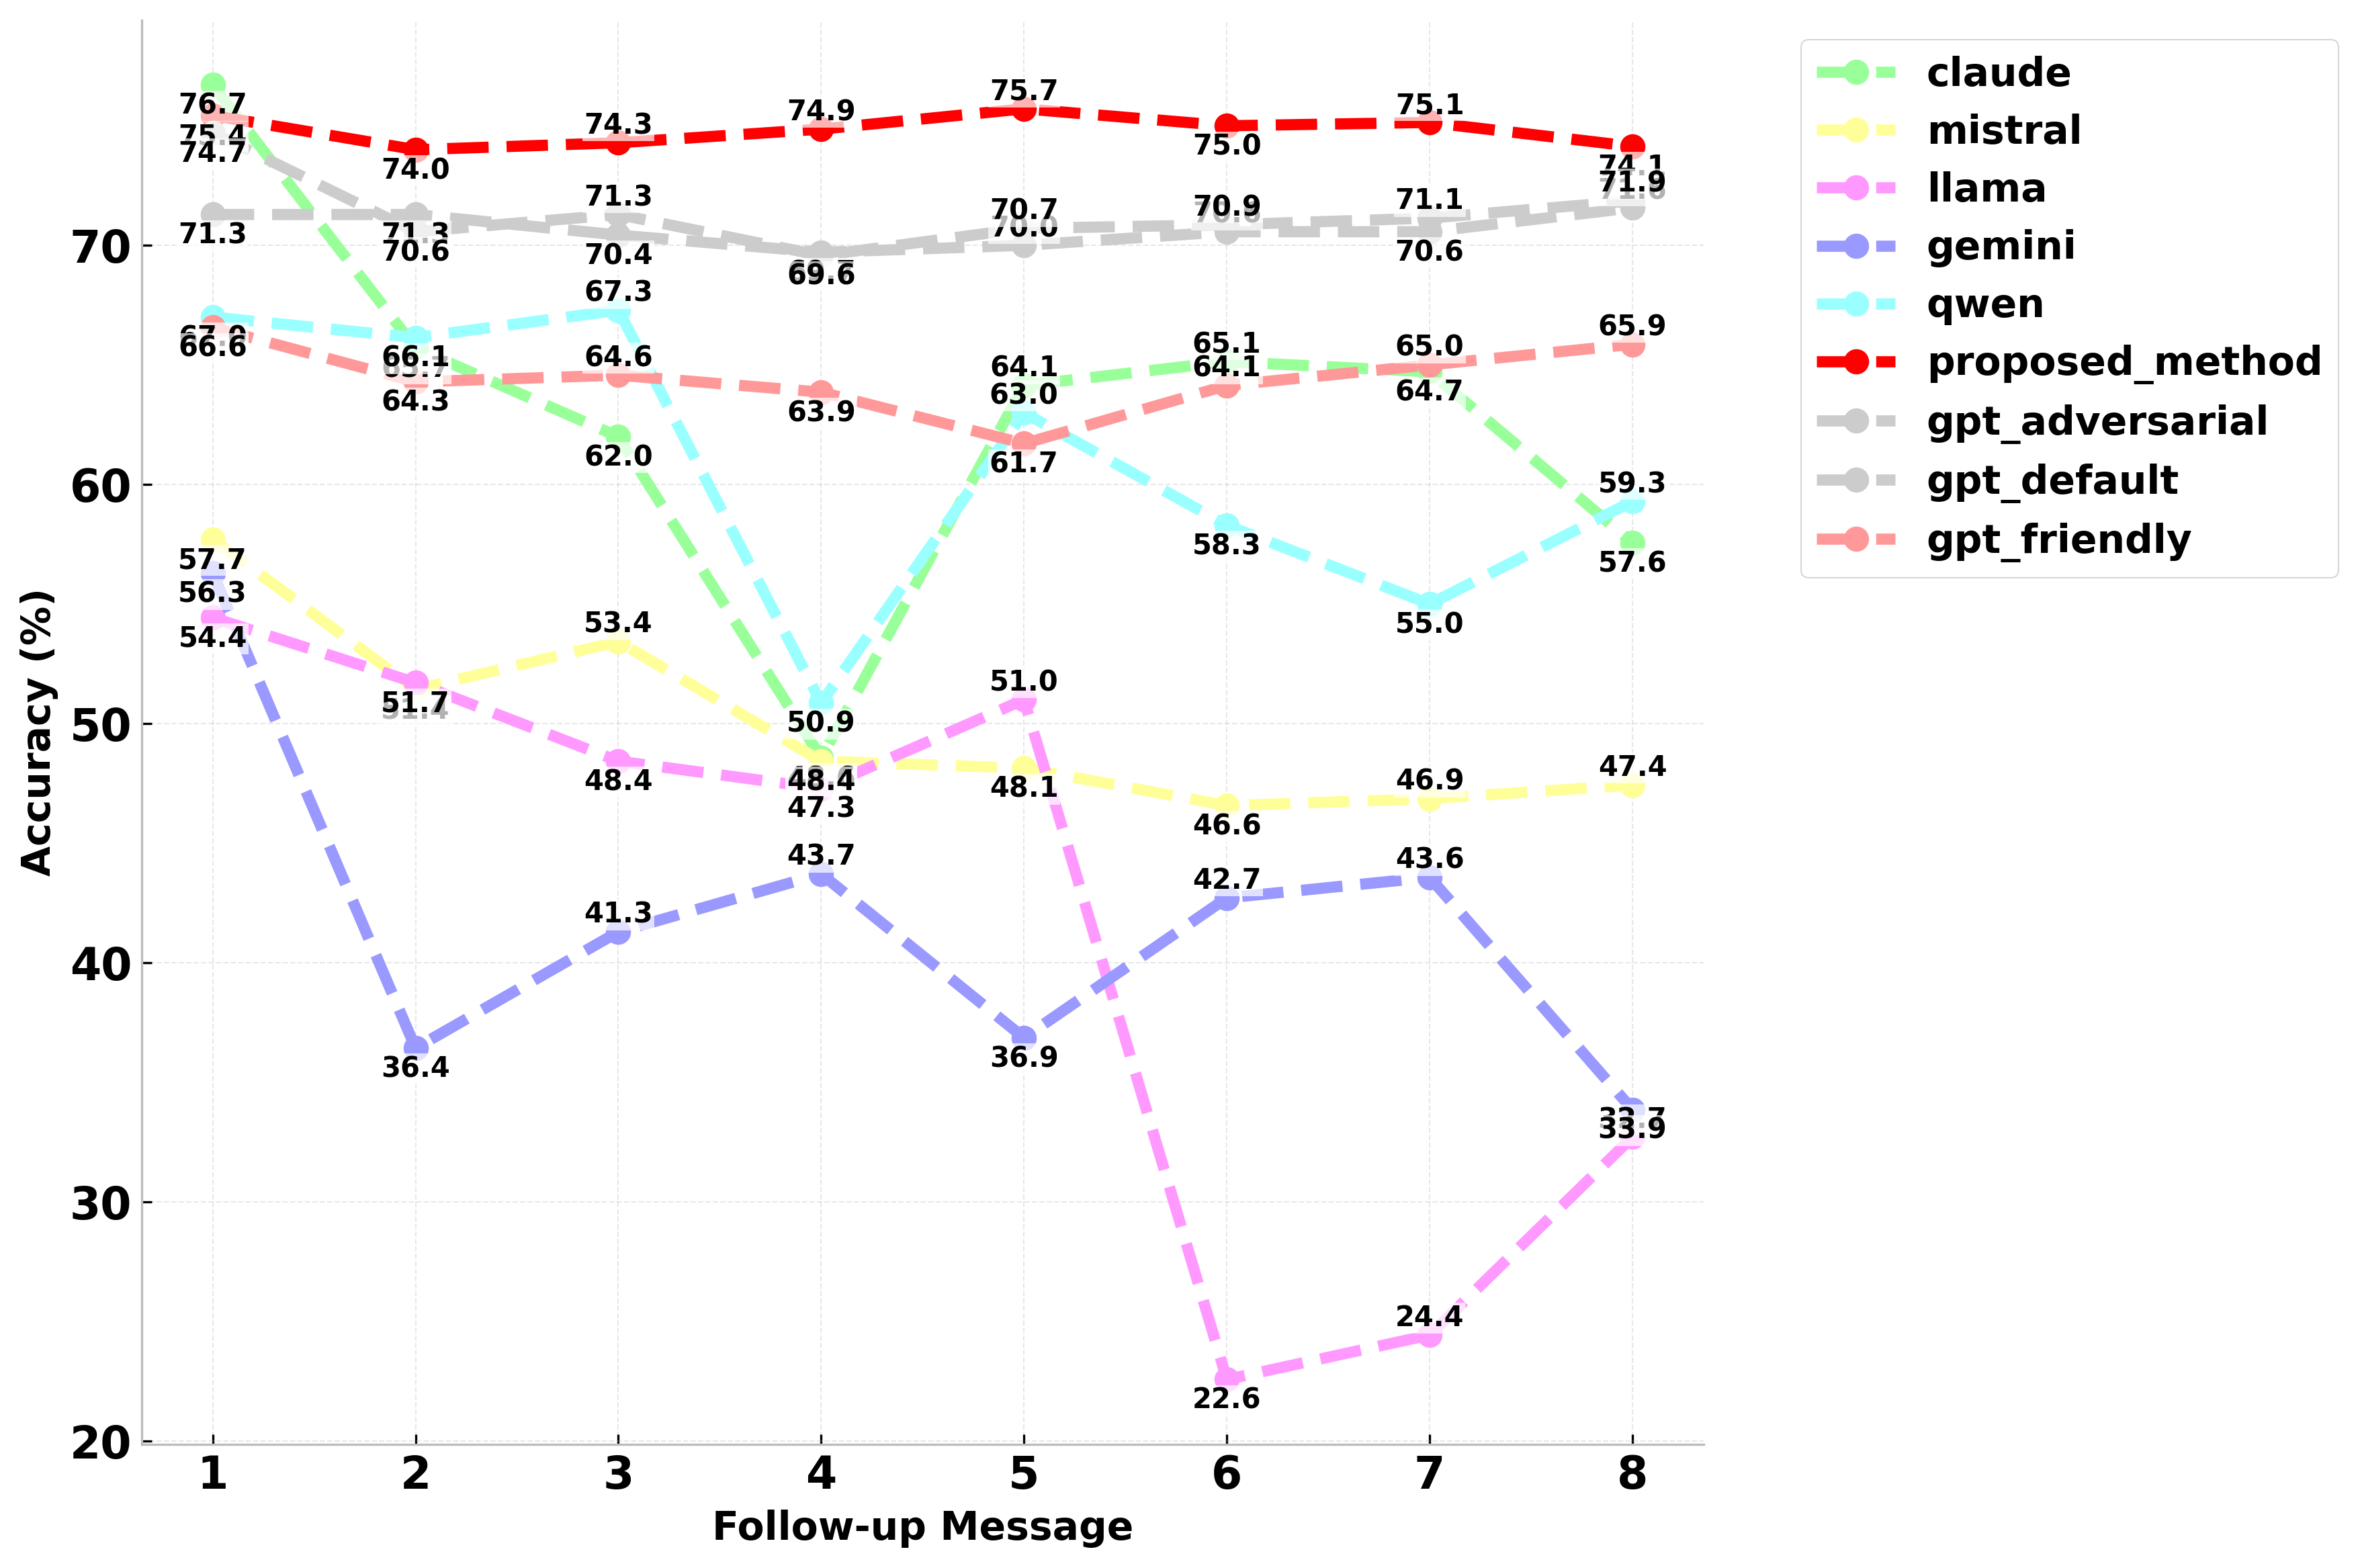


Summary Statistics for Each Model:

claude:
Initial accuracy: 76.71%
Final accuracy: 57.57%
Max accuracy: 76.71%
Min accuracy: 48.57%
Average accuracy: 63.07%

mistral:
Initial accuracy: 57.71%
Final accuracy: 47.43%
Max accuracy: 57.71%
Min accuracy: 46.57%
Average accuracy: 50.00%

llama:
Initial accuracy: 54.43%
Final accuracy: 32.71%
Max accuracy: 54.43%
Min accuracy: 22.57%
Average accuracy: 41.57%

gemini:
Initial accuracy: 56.29%
Final accuracy: 33.86%
Max accuracy: 56.29%
Min accuracy: 33.86%
Average accuracy: 41.84%

qwen:
Initial accuracy: 67.00%
Final accuracy: 59.29%
Max accuracy: 67.29%
Min accuracy: 50.86%
Average accuracy: 60.86%

proposed_method:
Initial accuracy: 75.43%
Final accuracy: 74.14%
Max accuracy: 75.71%
Min accuracy: 74.00%
Average accuracy: 74.82%

gpt_adversarial:
Initial accuracy: 71.29%
Final accuracy: 71.57%
Max accuracy: 71.57%
Min accuracy: 69.71%
Average accuracy: 70.68%

gpt_default:
Initial accuracy: 74.71%
Final accuracy: 71.86%
Max accuracy: 74.7

In [ ]:
def plot_model_round_accuracies(all_data_dict):
    """
    Plot accuracy trends across rounds for all models and save the data
    """
    # Create a DataFrame to store accuracies
    accuracy_data = []

    # Calculate accuracies for each model
    model_accuracies = {}
    for model_name, df in all_data_dict.items():
        accuracies = []
        for i in range(1, 9):
            round_col = f'round_{i}'
            total = len(df[round_col])
            correct = (df[round_col] == 1).sum()
            accuracy = (correct / total * 100) if total > 0 else 0
            accuracies.append(round(accuracy, 2))

            # Add to our data collection for DataFrame
            accuracy_data.append({
                'model': model_name,
                'round': i,
                'accuracy': round(accuracy, 2),
                'total_samples': total,
                'correct_samples': correct
            })

        model_accuracies[model_name] = accuracies

    # Create and save DataFrame
    accuracy_df = pd.DataFrame(accuracy_data)
    os.makedirs('cleaned_results/analysis', exist_ok=True)
    accuracy_df.to_csv('cleaned_results/analysis/model_accuracies.csv', index=False)

    # Plotting code remains the same
    plt.figure(figsize=(12, 8))

    # Color palette - make gpt_sol stand out with a distinct style
    color_palette = {
        'gpt': '#FF9999',        # Red family for GPT variants
        'gpt_42': '#FF9999',
        'gpt_friendly': '#FF9999',
        'gpt_adv': '#FF9999',
        'proposed_method': '#FF0000',
        'claude': '#99FF99',     # Green for Claude
        'gemini': '#9999FF',     # Blue for Gemini
        'mistral': '#FFFF99',    # Yellow for Mistral
        'llama': '#FF99FF',      # Purple for LLaMA
        'qwen': '#99FFFF'        # Cyan for Qwen
    }

    # Configure plot style manually for publication quality
    plt.rcParams.update({
        'figure.figsize': (10, 6),
        'figure.dpi': 300,
        'font.size': 14,
        'font.weight': 'bold',
        'font.family': 'DejaVu Sans',
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '-.',
        'axes.axisbelow': True,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 14,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1
    })

    # Line style dictionary - make gpt_sol line thicker
    line_styles = {
        'gpt_sol': {'linewidth': 6, 'markersize': 8, 'linestyle': '-'},
        'default': {'linewidth': 4, 'markersize': 8, 'linestyle': '--'}
    }

    # Plot lines for each model
    for model_name, accuracies in model_accuracies.items():
        # Get line style based on whether it's gpt_sol or not
        style = line_styles['gpt_sol'] if model_name == 'gpt_sol' else line_styles['default']

        plt.plot(range(1, 9), accuracies,
                marker='o',
                label=model_name,
                color=color_palette.get(model_name, '#CCCCCC'),
                **style)

        # Add annotations for all points with offset
        for i, accuracy in enumerate(accuracies):
            # Calculate offset direction based on trend
            if i > 0:
                offset_y = 1 if accuracies[i] > accuracies[i-1] else -2.5
            else:
                offset_y = -2.5

            plt.annotate(f'{accuracy:.1f}',
                        xy=(i + 1, accuracy),
                        xytext=(0, offset_y),
                        textcoords='offset points',
                        ha='center',
                        va='bottom' if offset_y > 0 else 'top',
                        fontsize=10,
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.5))

    # Customize the plot
    plt.xlabel('Follow-up Message',  fontweight='bold')
    plt.ylabel('Accuracy (%)',  fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.3)

    # Set x-axis ticks
    plt.xticks(range(1, 9))

    # Add legend with better placement
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Adjust layout
    plt.tight_layout()

    # Save plot
    os.makedirs('cleaned_results/plots', exist_ok=True)
    plt.savefig('cleaned_results/plots/model_round_accuracies_comparison_with_solution.png',
                bbox_inches='tight', dpi=300)
    plt.show()

    # Print summary statistics
    print("\nSummary Statistics for Each Model:")
    for model_name, accuracies in model_accuracies.items():
        print(f"\n{model_name}:")
        print(f"Initial accuracy: {accuracies[0]:.2f}%")
        print(f"Final accuracy: {accuracies[-1]:.2f}%")
        print(f"Max accuracy: {max(accuracies):.2f}%")
        print(f"Min accuracy: {min(accuracies):.2f}%")
        print(f"Average accuracy: {sum(accuracies)/len(accuracies):.2f}%")

    return accuracy_df  # Return the DataFrame for potential further analysis

# Read and process all model data
all_data = {}
for file_path in glob.glob('./cleaned_results/*.csv'):
    model_name = file_path.split('/')[-1].split('.')[0]
    data = pd.read_csv(file_path)
    if 'gpt' in model_name:
        data = transform_dataframe(data)
    if 'proposed'in model_name:
        data = transform_dataframe(data)
    all_data[model_name] = data

# Create the visualization and get the DataFrame
accuracy_df = plot_model_round_accuracies(all_data)

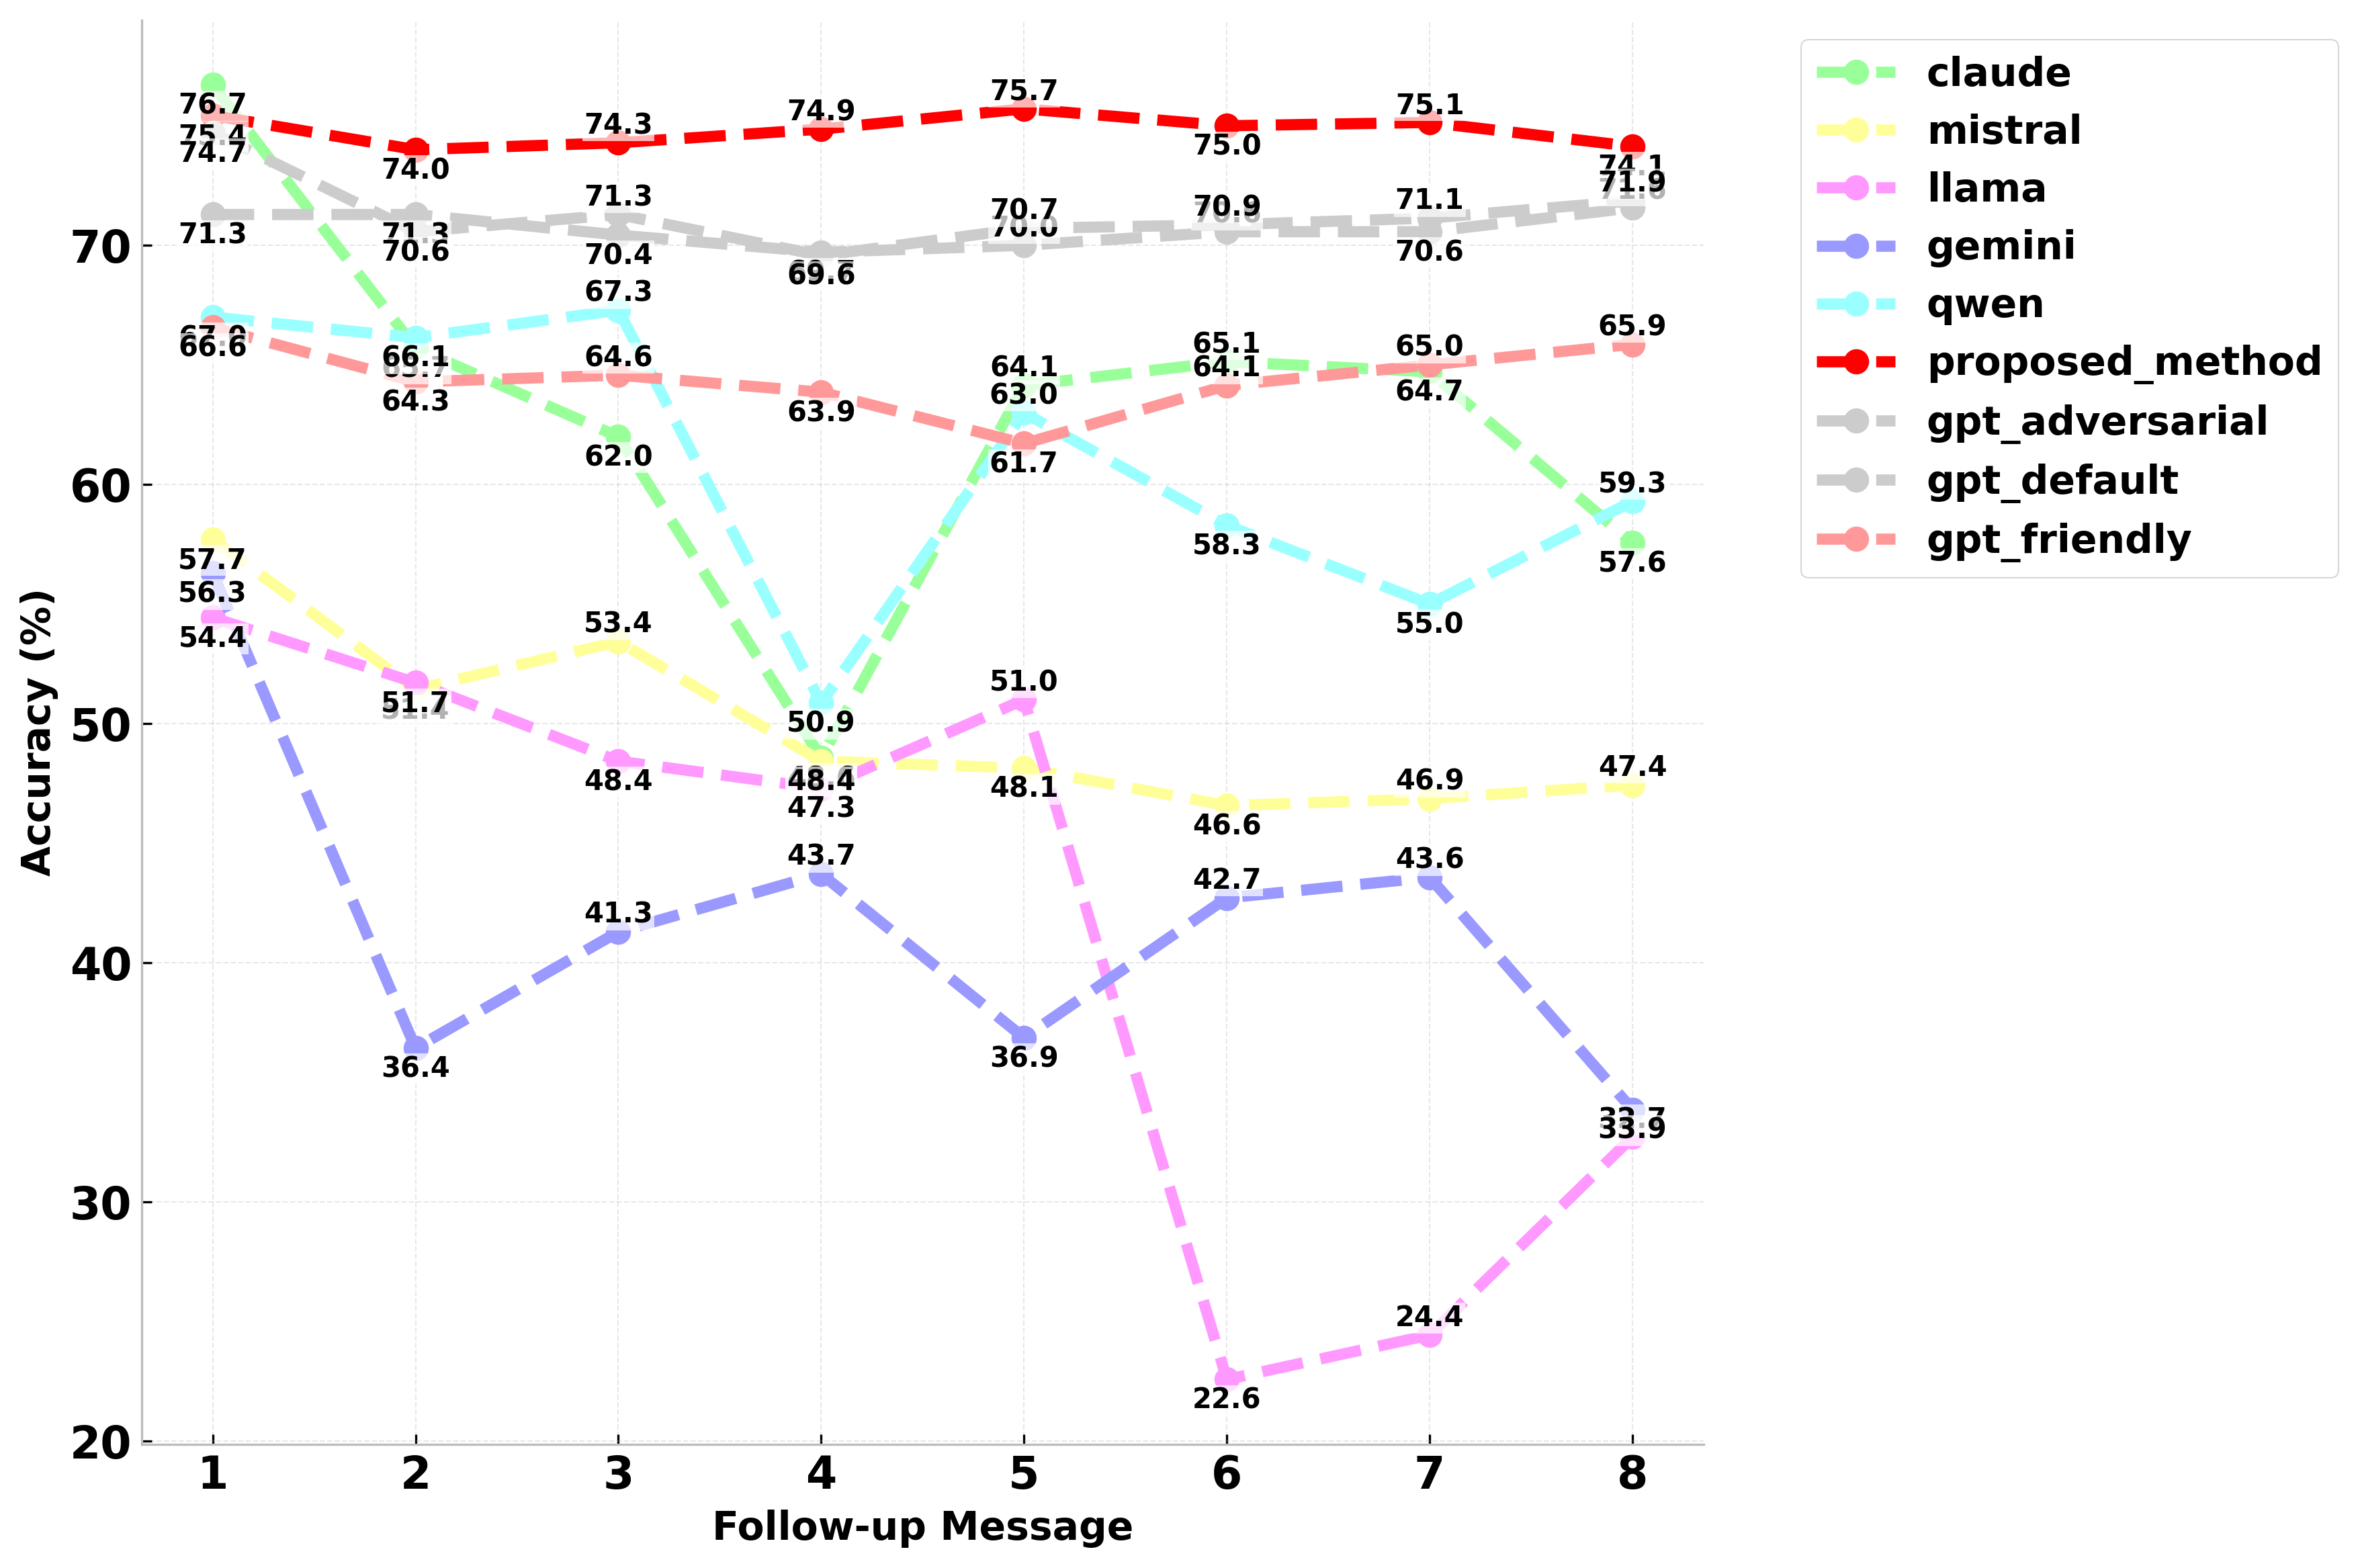


Summary Statistics for Each Model:

claude:
Initial accuracy: 76.71%
Final accuracy: 57.57%
Max accuracy: 76.71%
Min accuracy: 48.57%
Average accuracy: 63.07%

mistral:
Initial accuracy: 57.71%
Final accuracy: 47.43%
Max accuracy: 57.71%
Min accuracy: 46.57%
Average accuracy: 50.00%

llama:
Initial accuracy: 54.43%
Final accuracy: 32.71%
Max accuracy: 54.43%
Min accuracy: 22.57%
Average accuracy: 41.57%

gemini:
Initial accuracy: 56.29%
Final accuracy: 33.86%
Max accuracy: 56.29%
Min accuracy: 33.86%
Average accuracy: 41.84%

qwen:
Initial accuracy: 67.00%
Final accuracy: 59.29%
Max accuracy: 67.29%
Min accuracy: 50.86%
Average accuracy: 60.86%

proposed_method:
Initial accuracy: 75.43%
Final accuracy: 74.14%
Max accuracy: 75.71%
Min accuracy: 74.00%
Average accuracy: 74.82%

gpt_adversarial:
Initial accuracy: 71.29%
Final accuracy: 71.57%
Max accuracy: 71.57%
Min accuracy: 69.71%
Average accuracy: 70.68%

gpt_default:
Initial accuracy: 74.71%
Final accuracy: 71.86%
Max accuracy: 74.7

In [ ]:
def plot_model_round_accuracies(all_data_dict):
    """
    Plot accuracy trends across rounds for all models and save the data
    Returns:
        - accuracy_df: DataFrame with detailed accuracy data for each model and round
        - accuracy_matrix_df: DataFrame with models as rows and rounds as columns
    """
    # Create a DataFrame to store accuracies
    accuracy_data = []

    # Calculate accuracies for each model
    model_accuracies = {}
    for model_name, df in all_data_dict.items():
        accuracies = []
        for i in range(1, 9):
            round_col = f'round_{i}'
            total = len(df[round_col])
            correct = (df[round_col] == 1).sum()
            accuracy = (correct / total * 100) if total > 0 else 0
            accuracies.append(round(accuracy, 2))

            # Add to our data collection for DataFrame
            accuracy_data.append({
                'model': model_name,
                'round': i,
                'accuracy': round(accuracy, 2),
                'total_samples': total,
                'correct_samples': correct
            })

        model_accuracies[model_name] = accuracies

    # Create and save detailed DataFrame
    accuracy_df = pd.DataFrame(accuracy_data)
    os.makedirs('cleaned_results/analysis', exist_ok=True)
    accuracy_df.to_csv('cleaned_results/analysis/model_accuracies.csv', index=False)

    # Create matrix-style DataFrame (models as rows, rounds as columns)
    accuracy_matrix_df = pd.DataFrame.from_dict(model_accuracies, orient='index',
                                              columns=[f'round_{i}' for i in range(1, 9)])

    # Save matrix-style DataFrame
    accuracy_matrix_df.to_csv('cleaned_results/analysis/model_accuracies_matrix.csv')

    # Plotting code remains the same
    plt.figure(figsize=(12, 8))

    # Color palette - make gpt_sol stand out with a distinct style
    color_palette = {
        'gpt': '#FF9999',        # Red family for GPT variants
        'gpt_42': '#FF9999',
        'gpt_friendly': '#FF9999',
        'gpt_adv': '#FF9999',
        'proposed_method': '#FF0000',
        'claude': '#99FF99',     # Green for Claude
        'gemini': '#9999FF',     # Blue for Gemini
        'mistral': '#FFFF99',    # Yellow for Mistral
        'llama': '#FF99FF',      # Purple for LLaMA
        'qwen': '#99FFFF'        # Cyan for Qwen
    }

    # Configure plot style manually for publication quality
    plt.rcParams.update({
        'figure.figsize': (10, 6),
        'figure.dpi': 300,
        'font.size': 14,
        'font.weight': 'bold',
        'font.family': 'DejaVu Sans',
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '-.',
        'axes.axisbelow': True,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 14,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1
    })

    # Line style dictionary - make gpt_sol line thicker
    line_styles = {
        'gpt_sol': {'linewidth': 6, 'markersize': 8, 'linestyle': '-'},
        'default': {'linewidth': 4, 'markersize': 8, 'linestyle': '--'}
    }

    # Plot lines for each model
    for model_name, accuracies in model_accuracies.items():
        # Get line style based on whether it's gpt_sol or not
        style = line_styles['gpt_sol'] if model_name == 'gpt_sol' else line_styles['default']

        plt.plot(range(1, 9), accuracies,
                marker='o',
                label=model_name,
                color=color_palette.get(model_name, '#CCCCCC'),
                **style)

        # Add annotations for all points with offset
        for i, accuracy in enumerate(accuracies):
            # Calculate offset direction based on trend
            if i > 0:
                offset_y = 1 if accuracies[i] > accuracies[i-1] else -2.5
            else:
                offset_y = -2.5

            plt.annotate(f'{accuracy:.1f}',
                        xy=(i + 1, accuracy),
                        xytext=(0, offset_y),
                        textcoords='offset points',
                        ha='center',
                        va='bottom' if offset_y > 0 else 'top',
                        fontsize=10,
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.5))

    # Customize the plot
    plt.xlabel('Follow-up Message',  fontweight='bold')
    plt.ylabel('Accuracy (%)',  fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.3)

    # Set x-axis ticks
    plt.xticks(range(1, 9))

    # Add legend with better placement
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Adjust layout
    plt.tight_layout()

    # Save plot
    os.makedirs('cleaned_results/plots', exist_ok=True)
    plt.savefig('cleaned_results/plots/model_round_accuracies_comparison_with_solution.png',
                bbox_inches='tight', dpi=300)
    plt.show()

    # Print summary statistics
    print("\nSummary Statistics for Each Model:")
    for model_name, accuracies in model_accuracies.items():
        print(f"\n{model_name}:")
        print(f"Initial accuracy: {accuracies[0]:.2f}%")
        print(f"Final accuracy: {accuracies[-1]:.2f}%")
        print(f"Max accuracy: {max(accuracies):.2f}%")
        print(f"Min accuracy: {min(accuracies):.2f}%")
        print(f"Average accuracy: {sum(accuracies)/len(accuracies):.2f}%")

    return accuracy_df, accuracy_matrix_df  # Return both DataFrames for potential further analysis


# Read and process all model data
all_data = {}
for file_path in glob.glob('./cleaned_results/*.csv'):
    model_name = file_path.split('/')[-1].split('.')[0]
    data = pd.read_csv(file_path)
    if 'gpt' in model_name:
        data = transform_dataframe(data)
    if 'proposed'in model_name:
        data = transform_dataframe(data)
    all_data[model_name] = data

# Create the visualization and get the DataFrame
a,b = plot_model_round_accuracies(all_data)

In [ ]:
b.to_csv('appendix_table_exp_2_accuracy.csv', index=True)

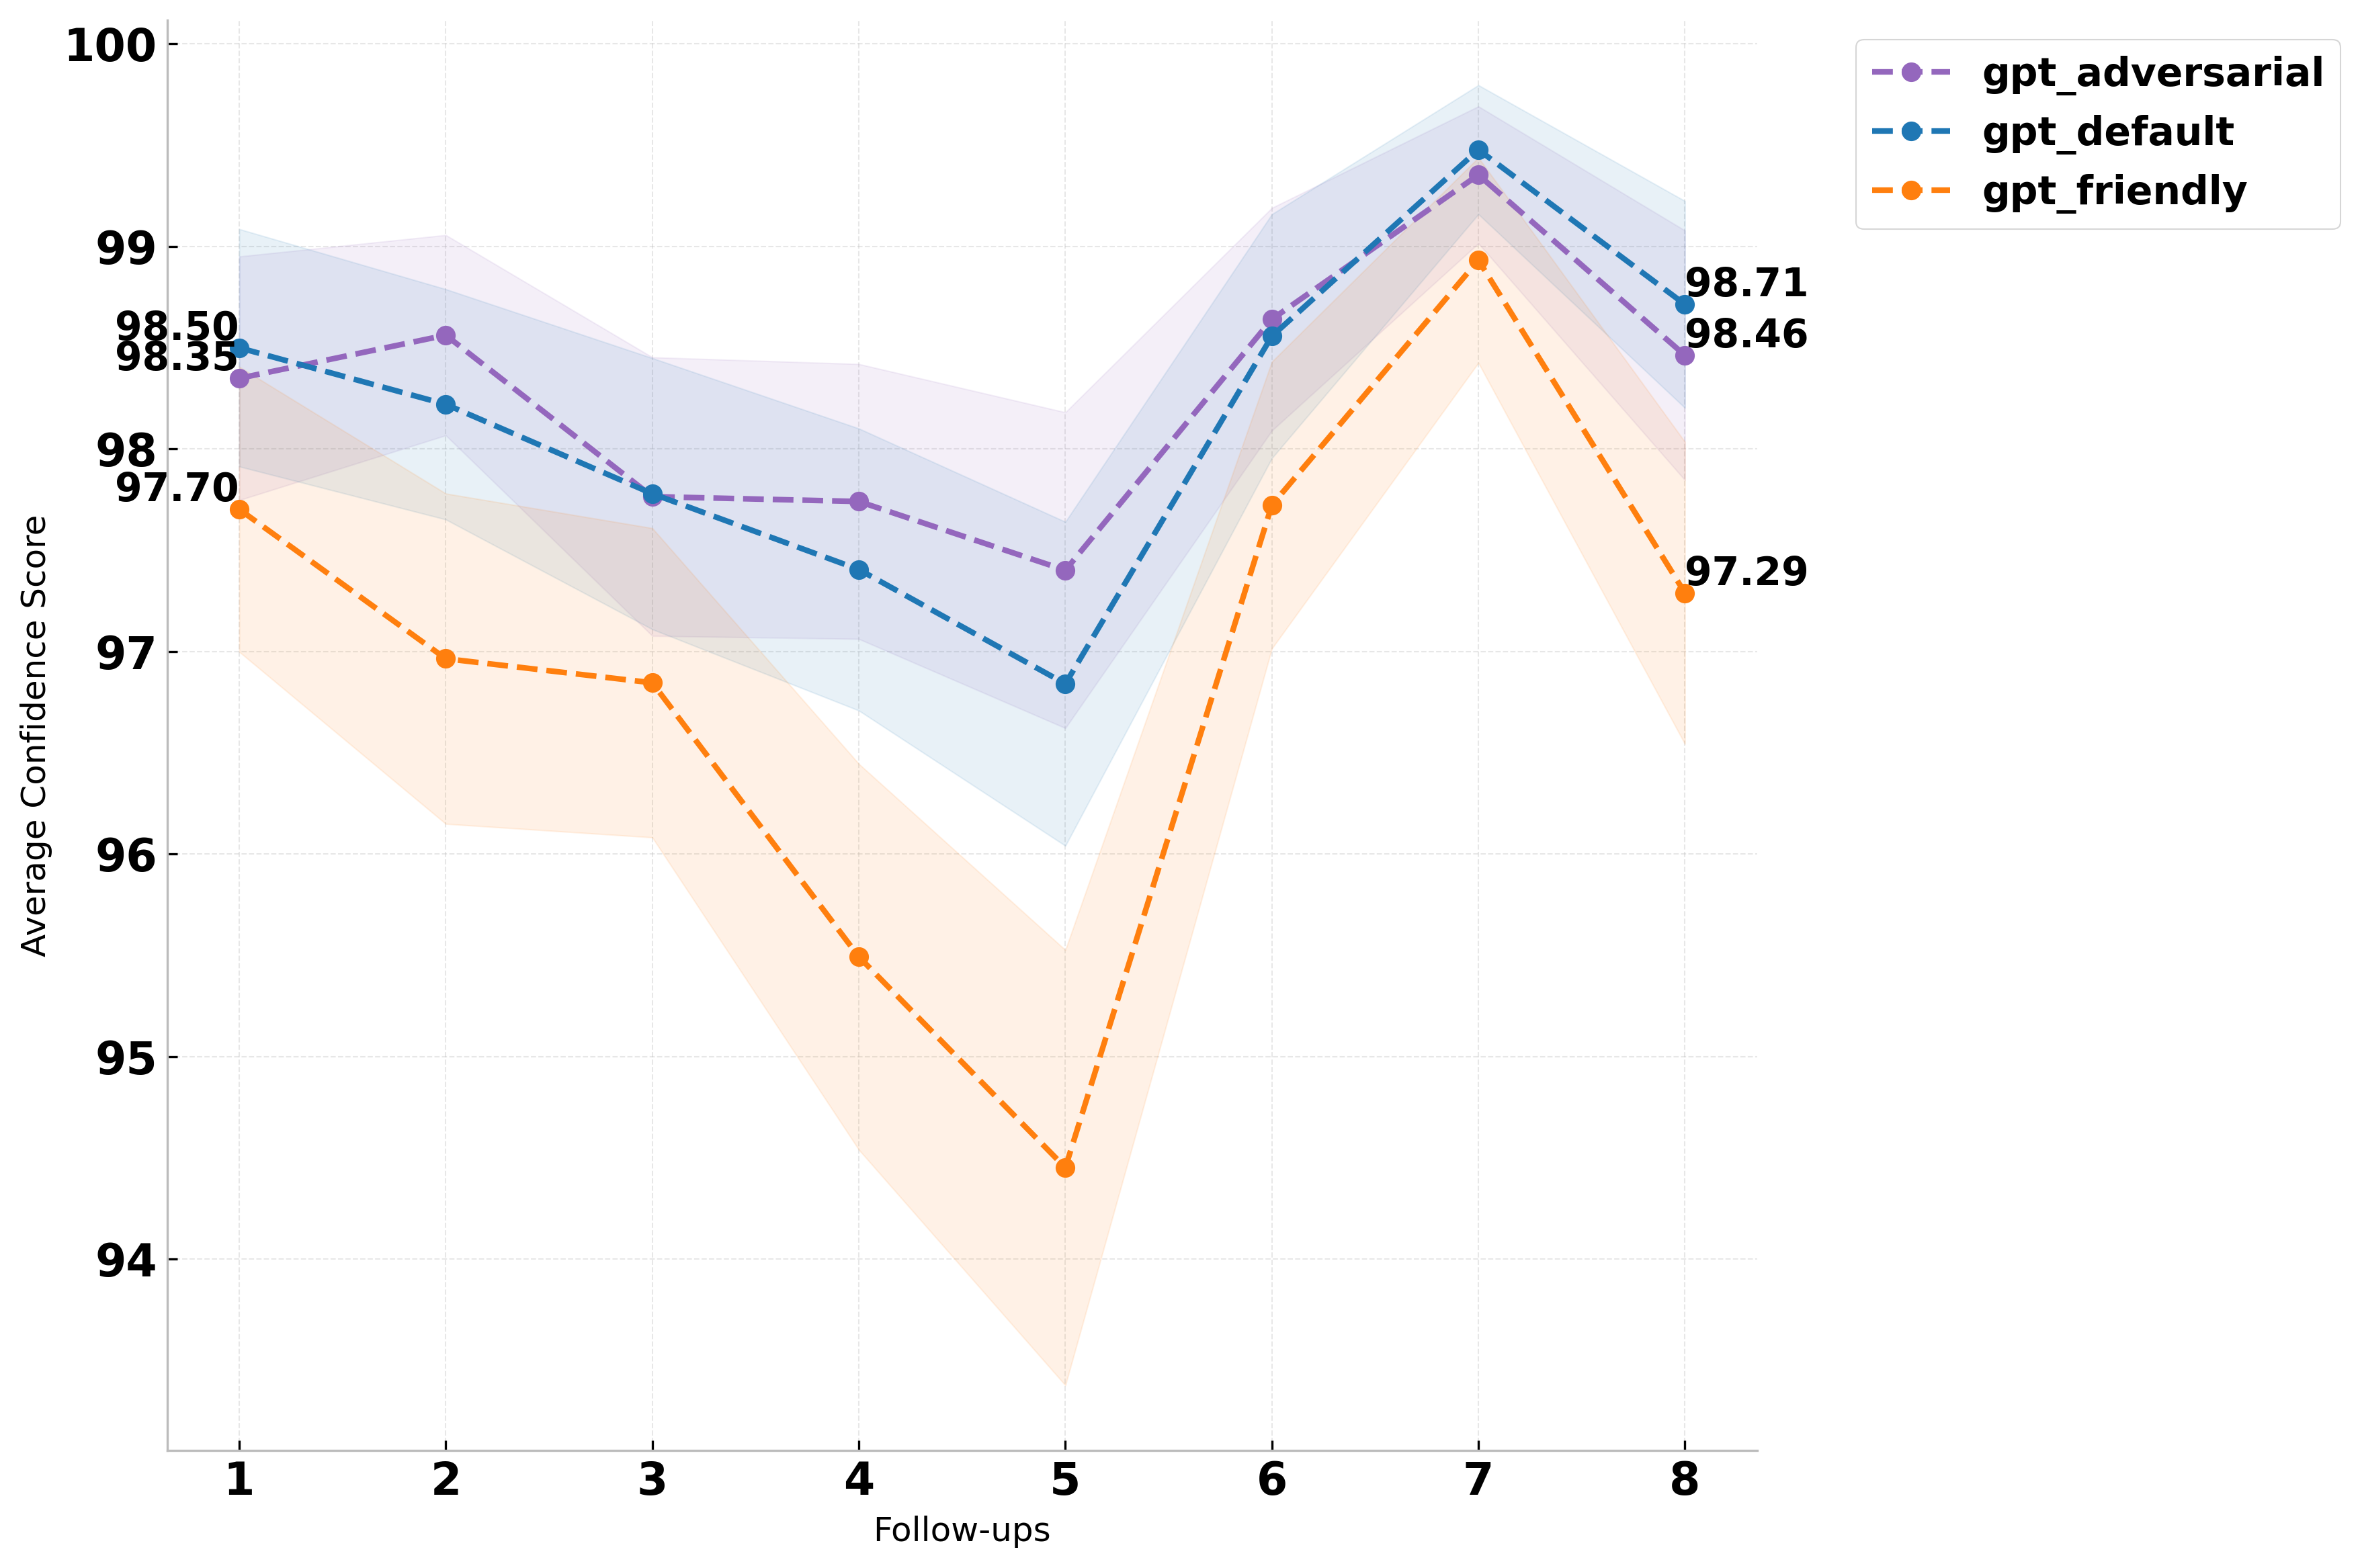


Confidence Summary Statistics for GPT Models:

gpt_adversarial:
Initial confidence: 98.35
Final confidence: 98.46
Average confidence: 98.28
Max confidence: 99.35
Min confidence: 97.40

gpt_default:
Initial confidence: 98.50
Final confidence: 98.71
Average confidence: 98.19
Max confidence: 99.48
Min confidence: 96.84

gpt_friendly:
Initial confidence: 97.70
Final confidence: 97.29
Average confidence: 96.93
Max confidence: 98.93
Min confidence: 94.45


In [ ]:
def plot_model_confidence_trends(all_data_dict):
    """
    Plot confidence trends across rounds for all GPT models
    """
    plt.figure(figsize=(12, 8))

    # Color palette for GPT variants
    color_palette = {
        'gpt_default': '#1f77b4',         # Blue
        'gpt_42': '#2ca02c',      # Green
        'gpt_friendly': '#ff7f0e', # Orange
        'gpt_adversarial': '#9467bd',     # Purple
        'gpt_sol': '#d62728'      # Red for solution
    }

    # Line style dictionary - make gpt_sol stand out
    line_styles = {
        'gpt_sol': {'linewidth': 3, 'markersize': 8, 'linestyle': '-'},
        'default': {'linewidth': 2, 'markersize': 6, 'linestyle': '--'}
    }

    # Plot each model's confidence
    for model_name, df in all_data_dict.items():
        if 'gpt' in model_name:  # Only process GPT models
            # Get confidence columns
            conf_cols = [f'round_{i}_conf' for i in range(1, 9)]

            # Calculate mean confidence for each round
            mean_conf = df[conf_cols].mean()

            # Calculate standard error for each round
            std_err = df[conf_cols].sem()

            # Get line style based on whether it's gpt_sol or not
            style = line_styles['gpt_sol'] if model_name == 'gpt_sol' else line_styles['default']

            # Plot mean confidence line
            plt.plot(range(1, 9), mean_conf.values,
                    marker='o',
                    label=model_name,
                    color=color_palette.get(model_name, '#CCCCCC'),
                    **style)

            # Add confidence interval
            plt.fill_between(range(1, 9),
                           mean_conf.values - 1.96 * std_err.values,
                           mean_conf.values + 1.96 * std_err.values,
                           alpha=0.1,
                           color=color_palette.get(model_name, '#CCCCCC'))

            # Add value labels for first and last points
            plt.text(1, mean_conf.values[0], f'{mean_conf.values[0]:.2f}',
                    ha='right', va='bottom')
            plt.text(8, mean_conf.values[-1], f'{mean_conf.values[-1]:.2f}',
                    ha='left', va='bottom')

    # Customize the plot
    plt.xlabel('Follow-ups', fontsize=12)
    plt.ylabel('Average Confidence Score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)

    # Set x-axis ticks
    plt.xticks(range(1, 9))

    # Add legend with better placement
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Adjust layout
    plt.tight_layout()

    # Save plot
    os.makedirs('cleaned_results/plots', exist_ok=True)
    plt.savefig('cleaned_results/plots/gpt_models_confidence_comparison.png',
                bbox_inches='tight', dpi=300)
    plt.show()

    # Print summary statistics
    print("\nConfidence Summary Statistics for GPT Models:")
    for model_name, df in all_data_dict.items():
        if 'gpt' in model_name:
            conf_cols = [f'round_{i}_conf' for i in range(1, 9)]
            mean_conf = df[conf_cols].mean()
            print(f"\n{model_name}:")
            print(f"Initial confidence: {mean_conf.values[0]:.2f}")
            print(f"Final confidence: {mean_conf.values[-1]:.2f}")
            print(f"Average confidence: {mean_conf.mean():.2f}")
            print(f"Max confidence: {mean_conf.max():.2f}")
            print(f"Min confidence: {mean_conf.min():.2f}")

# Read and process GPT model data
all_data = {}
for file_path in glob.glob('./cleaned_results/*.csv'):
    model_name = file_path.split('/')[-1].split('.')[0]
    if 'gpt' in model_name:
        data = pd.read_csv(file_path)
        data = transform_dataframe(data)
        all_data[model_name] = data

# Create the visualization
plot_model_confidence_trends(all_data)

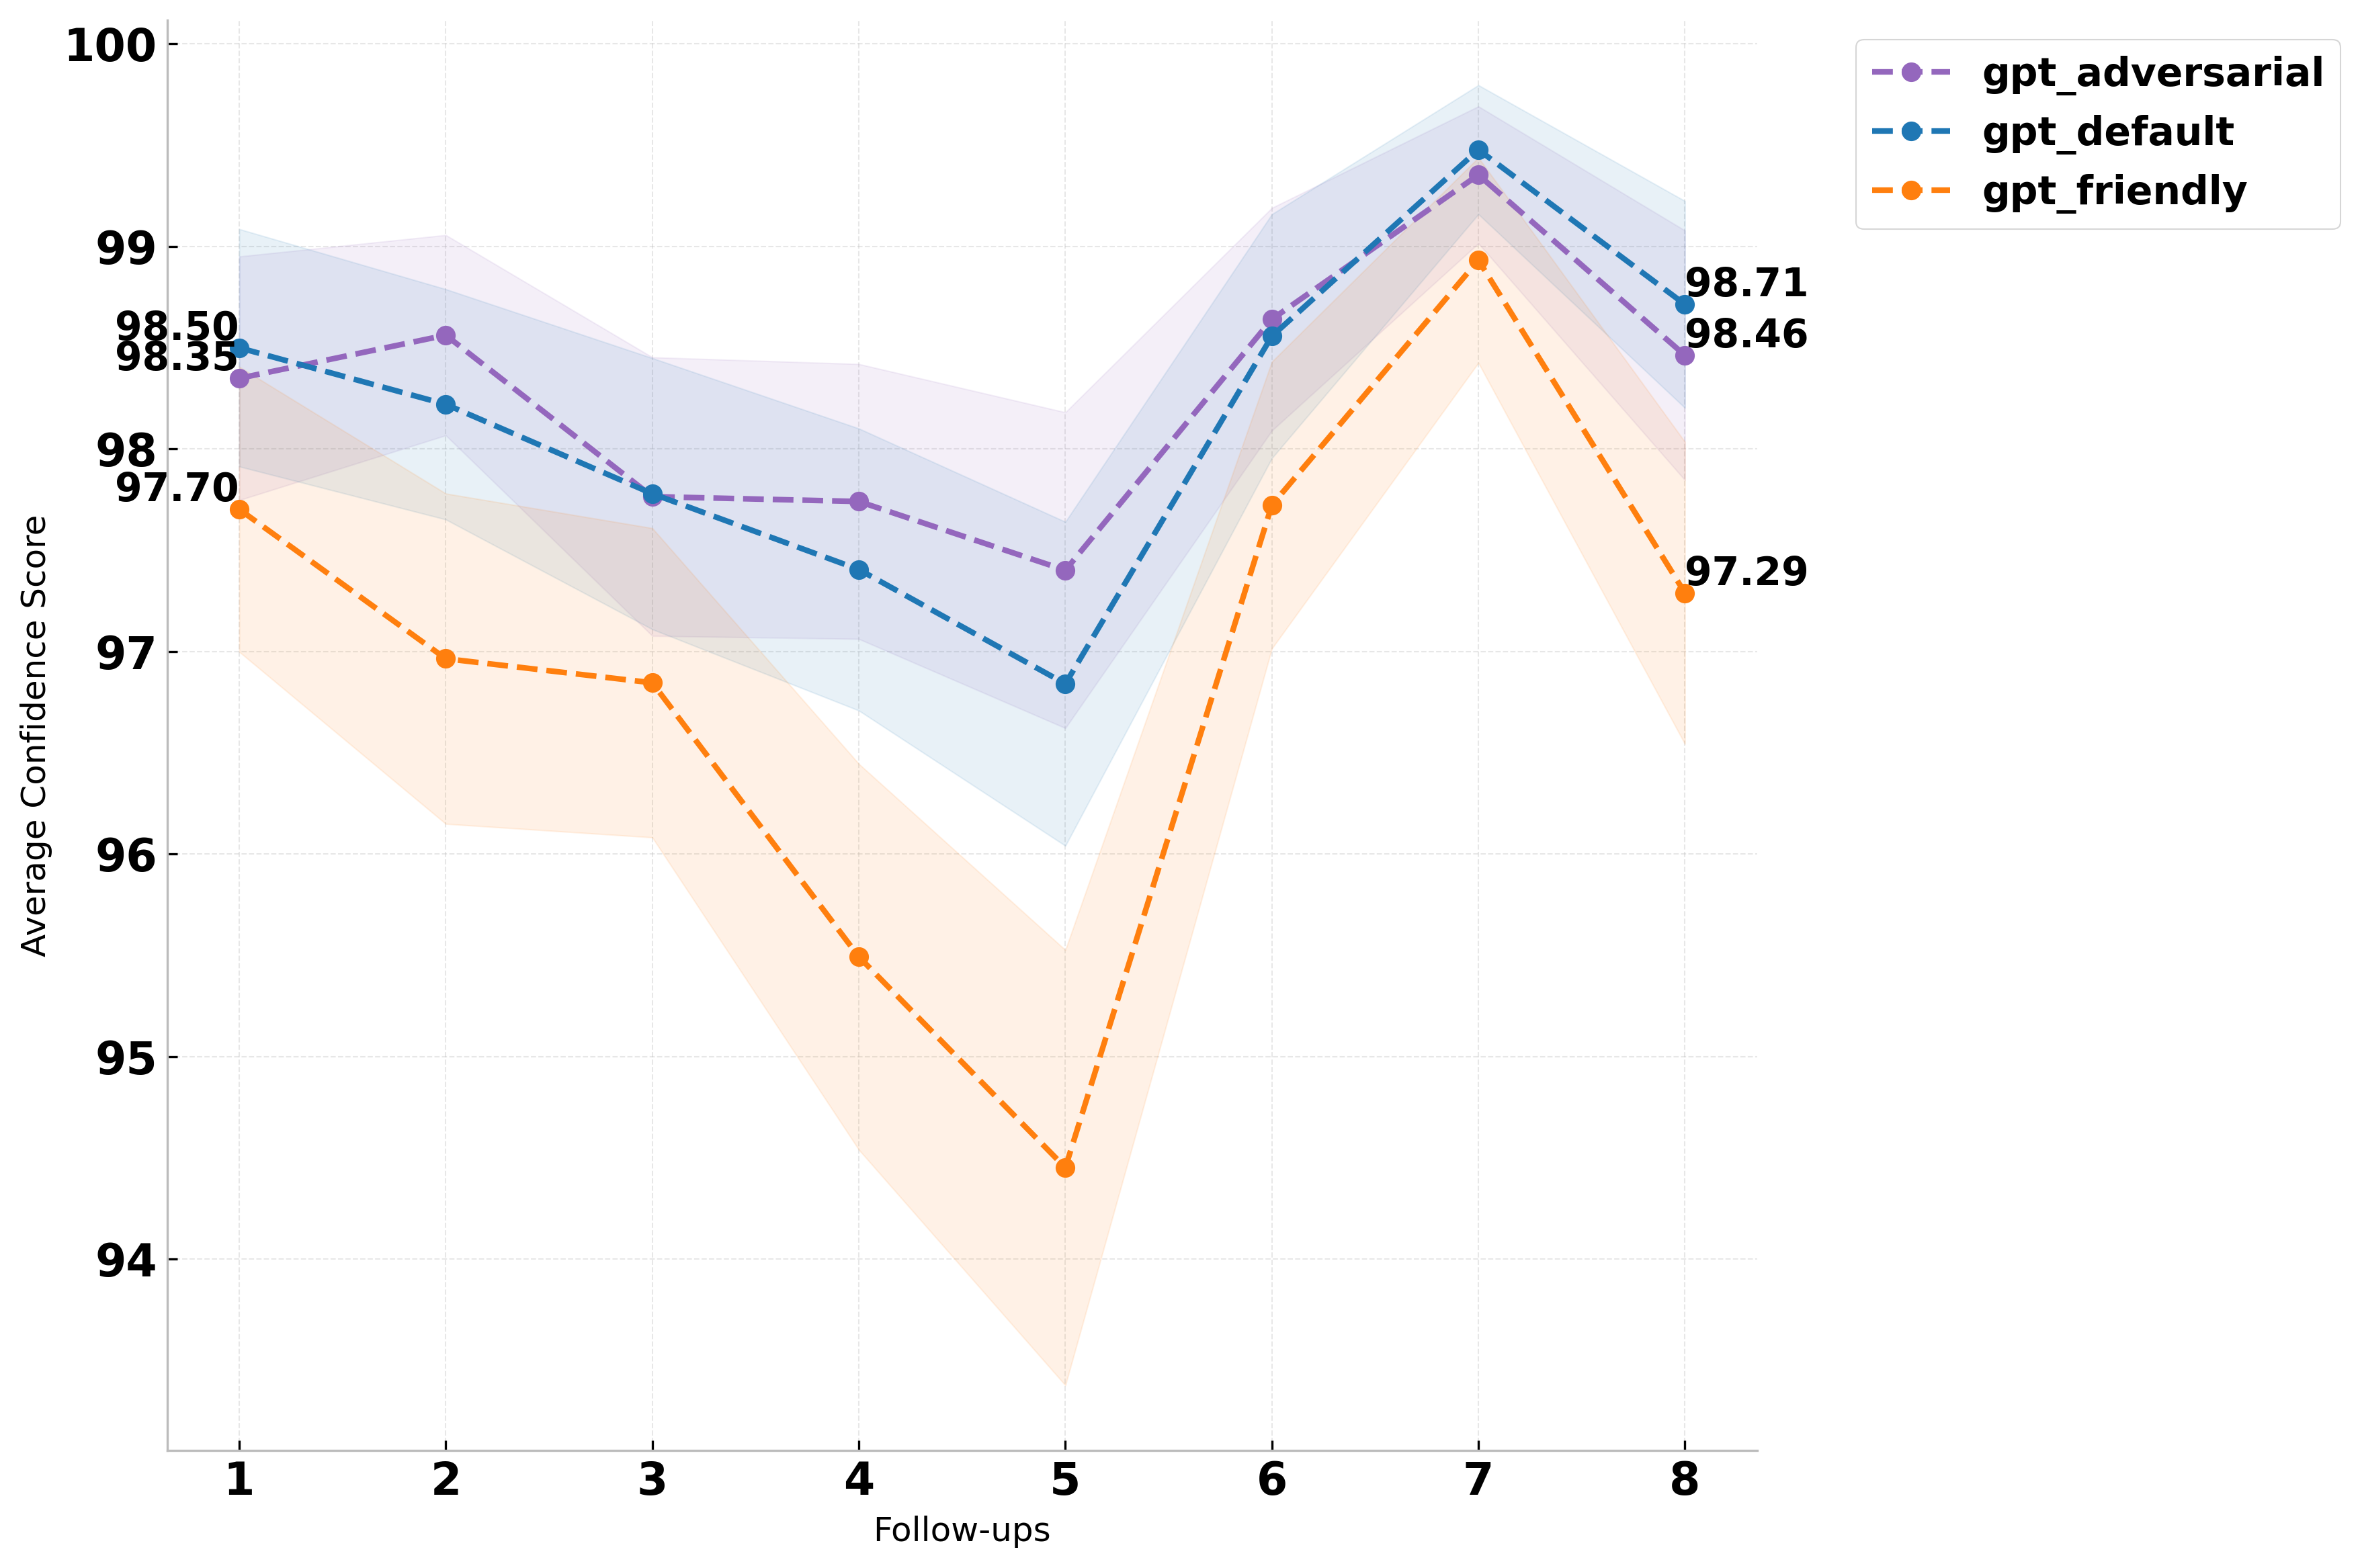


Confidence Summary Statistics for GPT Models:

gpt_adversarial:
Initial confidence: 98.35
Final confidence: 98.46
Average confidence: 98.28
Max confidence: 99.35
Min confidence: 97.40

gpt_default:
Initial confidence: 98.50
Final confidence: 98.71
Average confidence: 98.19
Max confidence: 99.48
Min confidence: 96.84

gpt_friendly:
Initial confidence: 97.70
Final confidence: 97.29
Average confidence: 96.93
Max confidence: 98.93
Min confidence: 94.45


In [ ]:
def plot_and_export_model_confidence(all_data_dict):
    """
    Plot confidence trends across rounds for all GPT models and export data as DataFrame
    Returns a DataFrame with confidence metrics for each model
    """
    plt.figure(figsize=(12, 8))

    # Color palette for GPT variants
    color_palette = {
        'gpt_default': '#1f77b4',         # Blue
        'gpt_42': '#2ca02c',      # Green
        'gpt_friendly': '#ff7f0e', # Orange
        'gpt_adversarial': '#9467bd',     # Purple
        'gpt_sol': '#d62728'      # Red for solution
    }

    # Line style dictionary - make gpt_sol stand out
    line_styles = {
        'gpt_sol': {'linewidth': 3, 'markersize': 8, 'linestyle': '-'},
        'default': {'linewidth': 2, 'markersize': 6, 'linestyle': '--'}
    }

    # Create empty lists to store data for DataFrame
    model_data = []

    # Plot each model's confidence
    for model_name, df in all_data_dict.items():
        if 'gpt' in model_name:  # Only process GPT models
            # Get confidence columns
            conf_cols = [f'round_{i}_conf' for i in range(1, 9)]

            # Calculate mean confidence for each round
            mean_conf = df[conf_cols].mean()

            # Calculate standard error for each round
            std_err = df[conf_cols].sem()

            # Store data for DataFrame
            model_row = {
                'model': model_name,
                'initial_confidence': mean_conf.values[0],
                'final_confidence': mean_conf.values[-1],
                'average_confidence': mean_conf.mean(),
                'max_confidence': mean_conf.max(),
                'min_confidence': mean_conf.min()
            }
            # Add each round's confidence
            for i, conf in enumerate(mean_conf.values, 1):
                model_row[f'round_{i}_confidence'] = conf
            model_data.append(model_row)

            # Get line style based on whether it's gpt_sol or not
            style = line_styles['gpt_sol'] if model_name == 'gpt_sol' else line_styles['default']

            # Plot mean confidence line
            plt.plot(range(1, 9), mean_conf.values,
                    marker='o',
                    label=model_name,
                    color=color_palette.get(model_name, '#CCCCCC'),
                    **style)

            # Add confidence interval
            plt.fill_between(range(1, 9),
                           mean_conf.values - 1.96 * std_err.values,
                           mean_conf.values + 1.96 * std_err.values,
                           alpha=0.1,
                           color=color_palette.get(model_name, '#CCCCCC'))

            # Add value labels for first and last points
            plt.text(1, mean_conf.values[0], f'{mean_conf.values[0]:.2f}',
                    ha='right', va='bottom')
            plt.text(8, mean_conf.values[-1], f'{mean_conf.values[-1]:.2f}',
                    ha='left', va='bottom')

    # Customize the plot
    plt.xlabel('Follow-ups', fontsize=12)
    plt.ylabel('Average Confidence Score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xticks(range(1, 9))
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Save plot
    os.makedirs('cleaned_results/plots', exist_ok=True)
    plt.savefig('cleaned_results/plots/gpt_models_confidence_comparison.png',
                bbox_inches='tight', dpi=300)
    plt.show()

    # Create and save DataFrame
    confidence_df = pd.DataFrame(model_data)

    # Reorder columns to have a logical sequence
    column_order = ['model', 'initial_confidence', 'final_confidence',
                   'average_confidence', 'max_confidence', 'min_confidence'] + \
                  [f'round_{i}_confidence' for i in range(1, 9)]
    confidence_df = confidence_df[column_order]

    # Save to CSV
    confidence_df.to_csv('cleaned_results/model_confidence_summary.csv', index=False)

    # Print summary statistics
    print("\nConfidence Summary Statistics for GPT Models:")
    for _, row in confidence_df.iterrows():
        print(f"\n{row['model']}:")
        print(f"Initial confidence: {row['initial_confidence']:.2f}")
        print(f"Final confidence: {row['final_confidence']:.2f}")
        print(f"Average confidence: {row['average_confidence']:.2f}")
        print(f"Max confidence: {row['max_confidence']:.2f}")
        print(f"Min confidence: {row['min_confidence']:.2f}")

    return confidence_df

# Read and process GPT model data
all_data = {}
for file_path in glob.glob('./cleaned_results/*.csv'):
    model_name = file_path.split('/')[-1].split('.')[0]
    if 'gpt' in model_name:
        data = pd.read_csv(file_path)
        data = transform_dataframe(data)
        all_data[model_name] = data

# Create the visualization and get the confidence DataFrame
confidence_df = plot_and_export_model_confidence(all_data)

In [ ]:
confidence_df

,model,initial_confidence,final_confidence,average_confidence,max_confidence,min_confidence,round_1_confidence,round_2_confidence,round_3_confidence,round_4_confidence,round_5_confidence,round_6_confidence,round_7_confidence,round_8_confidence
0,gpt_adversarial,98.349141,98.462691,98.284532,99.353492,97.401756,98.349141,98.562061,97.765229,97.741088,97.401756,98.640802,99.353492,98.462691
1,gpt_default,98.499835,98.713949,98.186913,99.477861,96.841060,98.499835,98.220676,97.779561,97.405265,96.841060,98.557093,99.477861,98.713949
2,gpt_friendly,97.702431,97.289763,96.925590,98.932213,94.452510,97.702431,96.964941,96.846087,95.493518,94.452510,97.723261,98.932213,97.289763


# Regression Analysis

In [ ]:
import pandas as pd
import numpy as np
import glob
import os

def find_first_sway(sequence):
    """
    Find the position of first change from 1 to 0.
    Assumes there's a '1' at position -1 before the sequence starts.
    Returns the round number (1-based) where first sway occurs, or 9 if no sway.
    """
    # Check if sequence starts with 0 (this counts as a sway from assumed 1 at -1)
    if len(sequence) > 0 and sequence[0] == 0:
        return 1

    # Check rest of sequence for 1->0 transition
    for i in range(len(sequence)-1):
        if sequence[i] == 1 and sequence[i+1] == 0:
            return i + 2  # Adding 2 because: +1 for next position, +1 for 1-based indexing

    return 8  # No sway occurred

# Get all CSV files
csv_files = glob.glob('./cleaned_results/*.csv')
csv_files.sort()

print(f"Found {len(csv_files)} CSV files:")
for file in csv_files:
    print(f"  - {os.path.basename(file)}")

# Define target models
target_models = ['gpt_default', 'proposed_method']  # Add more as needed

# Define round columns for rounds 1-8
round_columns = [f'round_{i}' for i in range(1, 9)]

# Store results per model
results_summary = {}

for target in target_models:
    print(f"\n🔍 Processing model: {target}")

    for file_path in csv_files:
        model_name = os.path.basename(file_path).replace('.csv', '')
        if model_name != target:
            continue

        print(f"  📁 Loading: {model_name}")
        df = pd.read_csv(file_path)
        print(f'  📊 Data loaded: {df.shape}')

        if 'round_0' not in df.columns:
            print(f"  ⚠️ No round_0 column found, skipping")
            continue

        # Filter data for calculations - only where round_0 != 0
        pwis_mask = df['round_0'] != 0
        pwis_data = df[pwis_mask].copy()
        print(f"  ✅ Valid rows for analysis: {len(pwis_data)}")

        # Initialize first sway column
        df['first_sway'] = None
        first_sways = []

        for idx, row in pwis_data.iterrows():
            # Get sequence for rounds 1-8
            raw_sequence = [row[col] for col in round_columns if col in df.columns]

            # Skip if sequence is incomplete
            if len(raw_sequence) != len(round_columns) or any(pd.isna(raw_sequence)):
                continue

            # Extract first element from tuples (prediction, confidence)
            sequence = []
            for item in raw_sequence:
                if isinstance(item, str) and item.startswith('(') and item.endswith(')'):
                    # Parse tuple string like "(1, 0.98)"
                    try:
                        # Remove parentheses and split by comma
                        clean_item = item.strip('()').split(',')
                        prediction = int(float(clean_item[0].strip()))
                        sequence.append(prediction)
                    except (ValueError, IndexError):
                        # If parsing fails, skip this sequence
                        sequence = []
                        break
                elif isinstance(item, tuple):
                    # Direct tuple
                    sequence.append(int(item[0]))
                else:
                    # Assume it's already a number
                    try:
                        sequence.append(int(float(item)))
                    except (ValueError, TypeError):
                        sequence = []
                        break

            # Skip if parsing failed
            if not sequence or len(sequence) != len(round_columns):
                continue

            # Calculate first sway
            first_sway = find_first_sway(sequence)
            first_sways.append(first_sway)

            # Store back into dataframe
            df.loc[idx, 'first_sway'] = first_sway

        # Calculate statistics
        if first_sways:
            print(f"  📊 First sway statistics:")
            print(f"    Total sequences analyzed: {len(first_sways)}")
            print(f"    Mean first sway round: {np.mean(first_sways):.2f}")
            print(f"    Std: {np.std(first_sways):.2f}")
            print(f"    Min: {min(first_sways)}")
            print(f"    Max: {max(first_sways)}")

            # Show distribution
            sway_counts = pd.Series(first_sways).value_counts().sort_index()
            print(f"    Distribution by round:")
            for round_num, count in sway_counts.items():
                percentage = (count / len(first_sways)) * 100
                print(f"      Round {round_num}: {count} ({percentage:.1f}%)")

            # Store results
            results_summary[model_name] = {
                'total_sequences': len(first_sways),
                'mean_first_sway': np.mean(first_sways),
                'std_first_sway': np.std(first_sways),
                'distribution': dict(sway_counts)
            }
        else:
            print(f"  ⚠️ No valid sequences found for {model_name}")

# Summary comparison
print(f"\n{'='*80}")
print("FIRST SWAY SUMMARY COMPARISON")
print(f"{'='*80}")

for model_name, stats in results_summary.items():
    print(f"\n===== {model_name} =====")
    print(f"Total sequences: {stats['total_sequences']}")
    print(f"Mean first sway round: {stats['mean_first_sway']:.2f}")
    print(f"Standard deviation: {stats['std_first_sway']:.2f}")
    print("Distribution:")
    for round_num in sorted(stats['distribution'].keys()):
        count = stats['distribution'][round_num]
        percentage = (count / stats['total_sequences']) * 100
        print(f"  Round {round_num}: {count:4d} ({percentage:5.1f}%)")

print(f"\n✅ Analysis complete!")

Found 9 CSV files:
  - claude.csv
  - gemini.csv
  - gpt_adversarial.csv
  - gpt_default.csv
  - gpt_friendly.csv
  - llama.csv
  - mistral.csv
  - proposed_method.csv
  - qwen.csv

🔍 Processing model: gpt_default
  📁 Loading: gpt_default
  📊 Data loaded: (700, 10)
  ✅ Valid rows for analysis: 547
  📊 First sway statistics:
    Total sequences analyzed: 547
    Mean first sway round: 6.84
    Std: 2.23
    Min: 1
    Max: 8
    Distribution by round:
      Round 1: 24 (4.4%)
      Round 2: 36 (6.6%)
      Round 3: 15 (2.7%)
      Round 4: 26 (4.8%)
      Round 5: 15 (2.7%)
      Round 6: 12 (2.2%)
      Round 7: 4 (0.7%)
      Round 8: 415 (75.9%)

🔍 Processing model: proposed_method
  📁 Loading: proposed_method
  📊 Data loaded: (700, 9)
  ✅ Valid rows for analysis: 548
  📊 First sway statistics:
    Total sequences analyzed: 548
    Mean first sway round: 7.44
    Std: 1.75
    Min: 1
    Max: 8
    Distribution by round:
      Round 1: 20 (3.6%)
      Round 2: 18 (3.3%)
      Round 3

Found 9 CSV files:
  - claude.csv
  - gemini.csv
  - gpt_adversarial.csv
  - gpt_default.csv
  - gpt_friendly.csv
  - llama.csv
  - mistral.csv
  - proposed_method.csv
  - qwen.csv

🔍 Processing model: gpt_default
  📁 Loading: gpt_default
  📊 Data loaded: (700, 10)
  ✅ Valid rows for analysis: 547
  📊 First sway statistics:
    Total sequences analyzed: 547
    Mean first sway round: 6.84
    Std: 2.23
    Min: 1
    Max: 8
    Distribution by round:
      Round 1: 24 (4.4%)
      Round 2: 36 (6.6%)
      Round 3: 15 (2.7%)
      Round 4: 26 (4.8%)
      Round 5: 15 (2.7%)
      Round 6: 12 (2.2%)
      Round 7: 4 (0.7%)
      Round 8: 415 (75.9%)

🔍 Processing model: proposed_method
  📁 Loading: proposed_method
  📊 Data loaded: (700, 9)
  ✅ Valid rows for analysis: 548
  📊 First sway statistics:
    Total sequences analyzed: 548
    Mean first sway round: 7.44
    Std: 1.75
    Min: 1
    Max: 8
    Distribution by round:
      Round 1: 20 (3.6%)
      Round 2: 18 (3.3%)
      Round 3

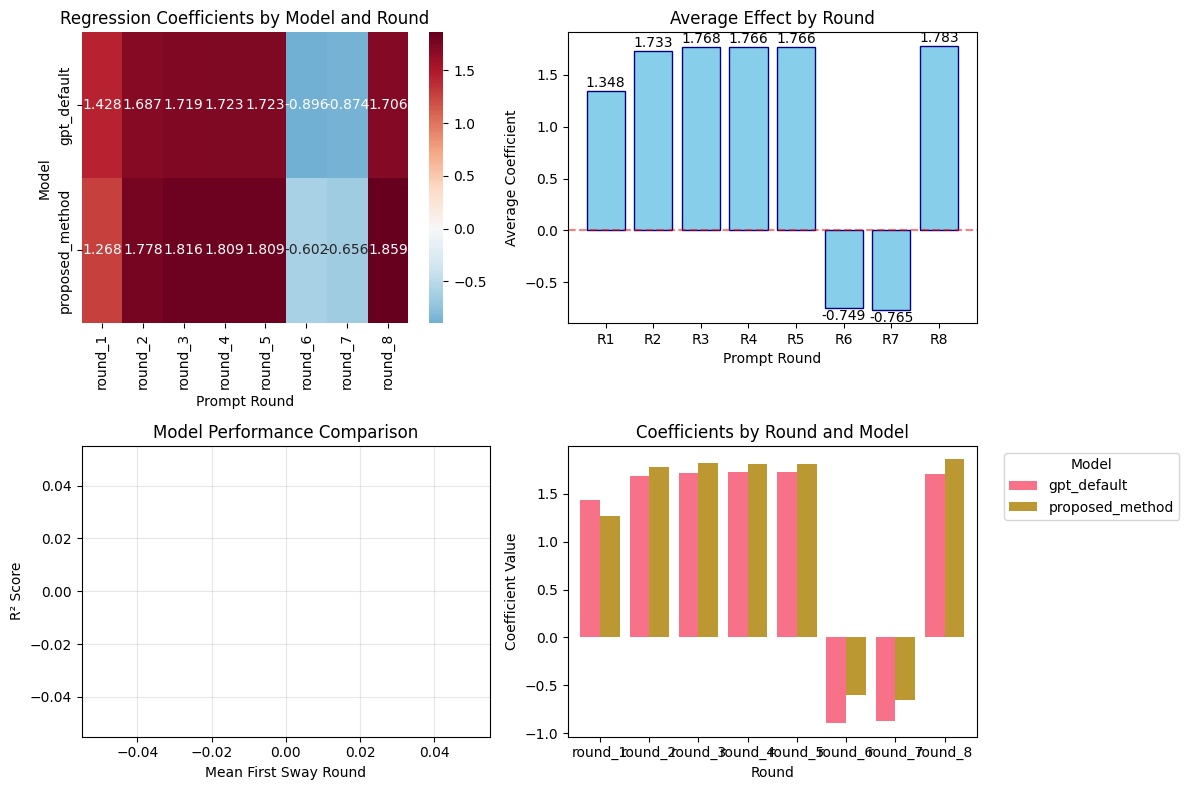

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

def find_first_sway(sequence):
    """
    Find the position of first change from 1 to 0.
    Assumes there's a '1' at position -1 before the sequence starts.
    Returns the round number (1-based) where first sway occurs, or 9 if no sway.
    """
    # Check if sequence starts with 0 (this counts as a sway from assumed 1 at -1)
    if len(sequence) > 0 and sequence[0] == 0:
        return 1

    # Check rest of sequence for 1->0 transition
    for i in range(len(sequence)-1):
        if sequence[i] == 1 and sequence[i+1] == 0:
            return i + 2  # Adding 2 because: +1 for next position, +1 for 1-based indexing

    return 8  # No sway occurred

# Get all CSV files
csv_files = glob.glob('./cleaned_results/*.csv')
csv_files.sort()

print(f"Found {len(csv_files)} CSV files:")
for file in csv_files:
    print(f"  - {os.path.basename(file)}")

# Define target models
target_models = ['gpt_default', 'proposed_method']  # Add more as needed

# Define round columns for rounds 1-8
round_columns = [f'round_{i}' for i in range(1, 9)]

# Store results per model
results_summary = {}

for target in target_models:
    print(f"\n🔍 Processing model: {target}")

    for file_path in csv_files:
        model_name = os.path.basename(file_path).replace('.csv', '')
        if model_name != target:
            continue

        print(f"  📁 Loading: {model_name}")
        df = pd.read_csv(file_path)
        print(f'  📊 Data loaded: {df.shape}')

        if 'round_0' not in df.columns:
            print(f"  ⚠️ No round_0 column found, skipping")
            continue

        # Filter data for calculations - only where round_0 != 0
        pwis_mask = df['round_0'] != 0
        pwis_data = df[pwis_mask].copy()
        print(f"  ✅ Valid rows for analysis: {len(pwis_data)}")

        # Initialize first sway column
        df['first_sway'] = None
        first_sways = []

        for idx, row in pwis_data.iterrows():
            # Get sequence for rounds 1-8
            raw_sequence = [row[col] for col in round_columns if col in df.columns]

            # Skip if sequence is incomplete
            if len(raw_sequence) != len(round_columns) or any(pd.isna(raw_sequence)):
                continue

            # Extract first element from tuples (prediction, confidence)
            sequence = []
            for item in raw_sequence:
                if isinstance(item, str) and item.startswith('(') and item.endswith(')'):
                    # Parse tuple string like "(1, 0.98)"
                    try:
                        # Remove parentheses and split by comma
                        clean_item = item.strip('()').split(',')
                        prediction = int(float(clean_item[0].strip()))
                        sequence.append(prediction)
                    except (ValueError, IndexError):
                        # If parsing fails, skip this sequence
                        sequence = []
                        break
                elif isinstance(item, tuple):
                    # Direct tuple
                    sequence.append(int(item[0]))
                else:
                    # Assume it's already a number
                    try:
                        sequence.append(int(float(item)))
                    except (ValueError, TypeError):
                        sequence = []
                        break

            # Skip if parsing failed
            if not sequence or len(sequence) != len(round_columns):
                continue

            # Calculate first sway
            first_sway = find_first_sway(sequence)
            first_sways.append(first_sway)

            # Store back into dataframe
            df.loc[idx, 'first_sway'] = first_sway

        # Calculate statistics
        if first_sways:
            print(f"  📊 First sway statistics:")
            print(f"    Total sequences analyzed: {len(first_sways)}")
            print(f"    Mean first sway round: {np.mean(first_sways):.2f}")
            print(f"    Std: {np.std(first_sways):.2f}")
            print(f"    Min: {min(first_sways)}")
            print(f"    Max: {max(first_sways)}")

            # Show distribution
            sway_counts = pd.Series(first_sways).value_counts().sort_index()
            print(f"    Distribution by round:")
            for round_num, count in sway_counts.items():
                percentage = (count / len(first_sways)) * 100
                print(f"      Round {round_num}: {count} ({percentage:.1f}%)")

            # Store results
            results_summary[model_name] = {
                'total_sequences': len(first_sways),
                'mean_first_sway': np.mean(first_sways),
                'std_first_sway': np.std(first_sways),
                'distribution': dict(sway_counts)
            }
        else:
            print(f"  ⚠️ No valid sequences found for {model_name}")

# Display summaries
print(f"\n{'='*80}")
print("REGRESSION RESULTS SUMMARY")
print(f"{'='*80}")

for model_name, result in model_results.items():
    model = result['model']
    print(f"\n===== Linear Regression Summary for {model_name} =====")
    print(f"Observations: {result['n_obs']}")
    print(f"Mean First Sway Round: {result['mean_first_sway']:.2f}")
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Adj. R-squared: {model.rsquared_adj:.4f}")
    print("\nCoefficients:")

    # Print coefficients in a clean format
    for coef_name, coef_val in model.params.items():
        if coef_name != 'const':
            p_val = model.pvalues[coef_name]
            sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
            print(f"  {coef_name:<12}: {coef_val:>8.4f} (p={p_val:.4f}) {sig}")

    print(f"\nFull Summary:")
    print(model.summary())

# Create simple visualization
if model_results:
    print(f"\n📊 Creating visualization...")

    # Extract coefficients for visualization
    models = list(model_results.keys())
    rounds = [f'round_{i}' for i in range(1, 9)]

    coef_data = []
    for model_name, result in model_results.items():
        model = result['model']
        coef_row = {'model': model_name}
        for round_name in rounds:
            if round_name in model.params.index:
                coef_row[round_name] = model.params[round_name]
            else:
                coef_row[round_name] = 0
        coef_data.append(coef_row)

    coef_df = pd.DataFrame(coef_data).set_index('model')

    # Create visualization
    plt.figure(figsize=(12, 8))

    # Subplot 1: Coefficient heatmap
    plt.subplot(2, 2, 1)
    sns.heatmap(coef_df, annot=True, cmap='RdBu_r', center=0, fmt='.3f')
    plt.title('Regression Coefficients by Model and Round')
    plt.xlabel('Prompt Round')
    plt.ylabel('Model')

    # Subplot 2: Average coefficients
    plt.subplot(2, 2, 2)
    avg_coefs = coef_df.mean(axis=0)
    bars = plt.bar(range(len(rounds)), avg_coefs.values, color='skyblue', edgecolor='navy')
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.xlabel('Prompt Round')
    plt.ylabel('Average Coefficient')
    plt.title('Average Effect by Round')
    plt.xticks(range(len(rounds)), [f'R{i+1}' for i in range(8)])

    # Add value labels
    for bar, val in zip(bars, avg_coefs.values):
        plt.text(bar.get_x() + bar.get_width()/2, val + (0.01 if val >= 0 else -0.01),
                f'{val:.3f}', ha='center', va='bottom' if val >= 0 else 'top')

    # Subplot 3: Model comparison
    plt.subplot(2, 2, 3)
    r2_scores = [result['model'].rsquared for result in model_results.values()]
    mean_sways = [result['mean_first_sway'] for result in model_results.values()]

    plt.scatter(mean_sways, r2_scores, s=100, alpha=0.7)
    for i, model in enumerate(models):
        plt.annotate(model, (mean_sways[i], r2_scores[i]),
                    xytext=(5, 5), textcoords='offset points')

    plt.xlabel('Mean First Sway Round')
    plt.ylabel('R² Score')
    plt.title('Model Performance Comparison')
    plt.grid(True, alpha=0.3)

    # Subplot 4: Coefficient range by round
    plt.subplot(2, 2, 4)
    coef_df.T.plot(kind='bar', ax=plt.gca(), width=0.8)
    plt.title('Coefficients by Round and Model')
    plt.xlabel('Round')
    plt.ylabel('Coefficient Value')
    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)

    plt.tight_layout()

    # Save plot
    os.makedirs('cleaned_results/plots', exist_ok=True)
    plt.savefig('cleaned_results/plots/simple_prompt_regression.png',
                dpi=300, bbox_inches='tight')
    plt.show()

<Axes: ylabel='model'>

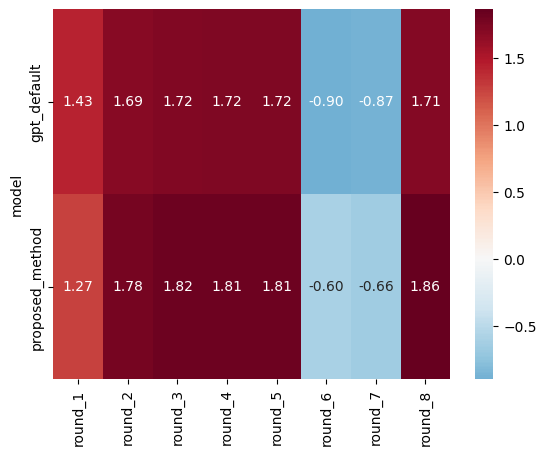

In [ ]:
# Build annotated heatmap with significance markers
annot = coef_df.copy()
for model_name, result in model_results.items():
    model = result['model']
    for round_name in rounds:
        coef = model.params.get(round_name, 0)
        p = model.pvalues.get(round_name, 1.0)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        annot.loc[model_name, round_name] = f'{coef:.2f}{sig}'

sns.heatmap(coef_df.astype(float), annot=annot, fmt='', cmap='RdBu_r', center=0)


In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

def find_first_sway(sequence):
    """
    Find the position of first change from 1 to 0.
    Assumes there's a '1' at position -1 before the sequence starts.
    Returns the round number (1-based) where first sway occurs, or 8 if no sway.
    """
    # Check if sequence starts with 0 (this counts as a sway from assumed 1 at -1)
    if len(sequence) > 0 and sequence[0] == 0:
        return 1

    # Check rest of sequence for 1->0 transition
    for i in range(len(sequence)-1):
        if sequence[i] == 1 and sequence[i+1] == 0:
            return i + 2  # Adding 2 because: +1 for next position, +1 for 1-based indexing

    return 8  # No sway occurred

def parse_prediction(item):
    """Parse prediction from various formats (tuple, string, number)"""
    if isinstance(item, str) and item.startswith('(') and item.endswith(')'):
        # Parse tuple string like "(1, 0.98)"
        try:
            clean_item = item.strip('()').split(',')
            prediction = int(float(clean_item[0].strip()))
            return prediction
        except (ValueError, IndexError):
            return None
    elif isinstance(item, tuple):
        # Direct tuple
        return int(item[0])
    else:
        # Assume it's already a number
        try:
            return int(float(item))
        except (ValueError, TypeError):
            return None

# Load QA metadata
print("📚 Loading QA metadata...")
qa_data = pd.read_csv('cleaned_data.csv')[['subject', 'level']]
print(f"Loaded metadata: {qa_data.shape}")
print(f"Subjects: {qa_data['subject'].value_counts().to_dict()}")
print(f"Levels: {qa_data['level'].value_counts().to_dict()}")

# Get all CSV files
csv_files = glob.glob('./cleaned_results/*.csv')
csv_files.sort()

print(f"\n📁 Found {len(csv_files)} CSV files:")
for file in csv_files:
    print(f"  - {os.path.basename(file)}")

# Define target models
target_models = ['gpt_default', 'proposed_method']
round_columns = [f'round_{i}' for i in range(1, 9)]

# Store results per model
model_results = {}
descriptive_stats = {}

print(f"\n{'='*80}")
print("REGRESSION ANALYSIS WITH SUBJECT AND LEVEL VARIABLES")
print(f"{'='*80}")

for target in target_models:
    print(f"\n🔍 Processing model: {target}")
    regression_data = []

    for file_path in csv_files:
        model_name = os.path.basename(file_path).replace('.csv', '')
        if model_name != target:
            continue

        print(f"  📁 Loading: {model_name}")
        df = pd.read_csv(file_path)
        print(f'  📊 Data loaded: {df.shape}')

        if 'round_0' not in df.columns:
            print(f"  ⚠️ No round_0 column found, skipping")
            continue

        # Merge metadata - align with dataframe length
        df = df.reset_index(drop=True)
        aligned_meta = qa_data.iloc[:len(df)].reset_index(drop=True)
        df = pd.concat([df, aligned_meta], axis=1)
        print(f"  ✅ Merged with metadata: {df.shape}")

        # Filter data for calculations - only where round_0 == 1 (correct initial prediction)
        valid_rows = df[df['round_0'] == 1]
        print(f"  ✅ Valid rows for analysis: {len(valid_rows)}")

        for idx, row in valid_rows.iterrows():
            # Get sequence for rounds 1-8
            raw_sequence = [row.get(col, np.nan) for col in round_columns]

            # Skip if sequence is incomplete
            if any(pd.isna(raw_sequence)):
                continue

            # Parse sequence
            sequence = []
            for item in raw_sequence:
                parsed = parse_prediction(item)
                if parsed is None:
                    sequence = []
                    break
                sequence.append(parsed)

            # Skip if parsing failed
            if not sequence or len(sequence) != len(round_columns):
                continue

            # Calculate first sway
            first_sway = find_first_sway(sequence)

            # Create predictor dictionary
            predictors = {}

            # Add round predictions as features
            for i, pred in enumerate(sequence, 1):
                predictors[f'round_{i}'] = pred

            # Add metadata
            predictors['subject'] = row['subject']
            predictors['level'] = row['level']
            predictors['first_sway'] = first_sway

            regression_data.append(predictors)

    # Convert to DataFrame
    regression_df = pd.DataFrame(regression_data)

    if regression_df.empty or 'first_sway' not in regression_df.columns:
        print(f"  ⚠️ Skipping model {target} due to empty or invalid data.")
        continue

    print(f"  📊 Regression dataset created: {regression_df.shape}")
    print(f"  📊 Subjects in data: {regression_df['subject'].value_counts().to_dict()}")
    print(f"  📊 Levels in data: {regression_df['level'].value_counts().to_dict()}")

    # Store descriptive statistics
    descriptive_stats[target] = {
        'total_observations': len(regression_df),
        'mean_first_sway': regression_df['first_sway'].mean(),
        'std_first_sway': regression_df['first_sway'].std(),
        'subject_distribution': regression_df['subject'].value_counts().to_dict(),
        'level_distribution': regression_df['level'].value_counts().to_dict(),
        'first_sway_by_subject': regression_df.groupby('subject')['first_sway'].mean().to_dict(),
        'first_sway_by_level': regression_df.groupby('level')['first_sway'].mean().to_dict()
    }

    # Check for missing values and data quality
    print(f"  📊 Missing values in subject: {regression_df['subject'].isna().sum()}")
    print(f"  📊 Missing values in level: {regression_df['level'].isna().sum()}")

    # Clean missing values before analysis
    regression_df = regression_df.dropna(subset=['subject', 'level'])
    print(f"  📊 After removing missing values: {regression_df.shape}")

    if regression_df.empty:
        print(f"  ⚠️ No valid data remaining after removing missing values for {target}")
        continue

    # Check what categories exist before encoding
    unique_subjects = [x for x in regression_df['subject'].unique() if pd.notna(x)]
    unique_levels = [x for x in regression_df['level'].unique() if pd.notna(x)]

    print(f"  📊 Original subjects: {sorted(unique_subjects)}")
    print(f"  📊 Original levels: {sorted(unique_levels)}")

    # One-hot encode categorical variables
    regression_df_encoded = pd.get_dummies(regression_df, columns=['subject', 'level'], drop_first=False)
    print(f"  📊 After encoding: {regression_df_encoded.shape}")
    print(f"  📊 New columns: {[col for col in regression_df_encoded.columns if col not in regression_df.columns]}")

    # Show which categories were dropped (reference categories)
    encoded_subjects = [col.replace('subject_', '') for col in regression_df_encoded.columns if col.startswith('subject_')]
    encoded_levels = [col.replace('level_', '') for col in regression_df_encoded.columns if col.startswith('level_')]

    dropped_subject = [s for s in unique_subjects if s not in encoded_subjects]
    dropped_level = [l for l in unique_levels if l not in encoded_levels]

    print(f"  📊 Reference (dropped) subject: {dropped_subject}")
    print(f"  📊 Reference (dropped) level: {dropped_level}")

    # Separate features and target
    X = regression_df_encoded.drop(columns=['first_sway'])
    y = regression_df_encoded['first_sway']

    # Clean and enforce types
    X = X.apply(pd.to_numeric, errors='coerce')
    y = pd.to_numeric(y, errors='coerce')

    # Drop rows with any NaNs
    df_clean = pd.concat([X, y], axis=1).dropna()
    if df_clean.empty:
        print(f"  ⚠️ Skipping model {target} due to empty data after cleaning.")
        continue

    X = df_clean.drop(columns=['first_sway'])
    y = df_clean['first_sway']

    print(f"  📊 Final dataset for regression: {X.shape}, target: {len(y)}")

    if len(X) == 0 or len(y) == 0:
        print(f"  ⚠️ Skipping model {target} due to zero-sized input after filtering.")
        continue

    # Add constant for intercept
    X_with_const = sm.add_constant(X)

    # Fit OLS model
    model = sm.OLS(y.astype(float), X_with_const.astype(float)).fit()

    # Calculate additional metrics
    y_pred = model.predict(X_with_const.astype(float))
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)

    # Store results
    model_results[target] = {
        'model': model,
        'n_obs': len(y),
        'mean_first_sway': y.mean(),
        'std_first_sway': y.std(),
        'r_squared': model.rsquared,
        'adj_r_squared': model.rsquared_adj,
        'mse': mse,
        'rmse': rmse,
        'aic': model.aic,
        'bic': model.bic,
        'data': regression_df,
        'encoded_data': regression_df_encoded,
        'X': X,
        'y': y,
        'predictions': y_pred
    }

    print(f"  ✅ Regression completed for {target}")
    print(f"     - R-squared: {model.rsquared:.3f}")
    print(f"     - Adj R-squared: {model.rsquared_adj:.3f}")
    print(f"     - RMSE: {rmse:.3f}")
# Display Results
print(f"\n{'='*80}")
print("DESCRIPTIVE STATISTICS BY MODEL")
print(f"{'='*80}")

for model_name, stats in descriptive_stats.items():
    print(f"\n===== {model_name.upper()} =====")
    print(f"Total observations: {stats['total_observations']}")
    print(f"Mean first sway: {stats['mean_first_sway']:.2f} ± {stats['std_first_sway']:.2f}")

    print(f"\nFirst sway by subject:")
    for subject, mean_sway in stats['first_sway_by_subject'].items():
        print(f"  {subject}: {mean_sway:.2f}")

    print(f"\nFirst sway by level:")
    for level, mean_sway in stats['first_sway_by_level'].items():
        print(f"  {level}: {mean_sway:.2f}")

print(f"\n{'='*80}")
print("REGRESSION RESULTS SUMMARY")
print(f"{'='*80}")

for model_name, results in model_results.items():
    print(f"\n===== {model_name.upper()} REGRESSION =====")
    print(f"Observations: {results['n_obs']}")
    print(f"R-squared: {results['r_squared']:.3f}")
    print(f"Adjusted R-squared: {results['adj_r_squared']:.3f}")
    print(f"RMSE: {results['rmse']:.3f}")
    print(f"AIC: {results['aic']:.1f}")
    print(f"BIC: {results['bic']:.1f}")

    print(f"\nCoefficients:")
    model = results['model']
    for param, coef in model.params.items():
        pval = model.pvalues[param]
        significance = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        print(f"  {param:20s}: {coef:8.3f} (p={pval:.3f}) {significance}")

print(f"\n{'='*80}")
print("DETAILED REGRESSION OUTPUT")
print(f"{'='*80}")

for model_name, results in model_results.items():
    print(f"\n===== {model_name.upper()} DETAILED OUTPUT =====")
    print(results['model'].summary())
    print(f"\n{'-'*60}")

print(f"\n✅ Complete regression analysis finished!")
print(f"📊 Models analyzed: {list(model_results.keys())}")
print(f"📊 Variables included: Round predictions, Subject, Level")
print(f"📊 Target variable: First sway round (1-8)")

# Save regression results to CSV files
print(f"\n{'='*80}")
print("SAVING REGRESSION RESULTS TO CSV")
print(f"{'='*80}")

# Create results directory if it doesn't exist
import os
os.makedirs('regression_results', exist_ok=True)

# 1. Save individual model results
for model_name, results in model_results.items():
    model = results['model']

    # Extract coefficient information
    coef_data = []
    for param in model.params.index:
        coef_data.append({
            'variable': param,
            'coefficient': model.params[param],
            'std_error': model.bse[param],
            't_statistic': model.tvalues[param],
            'p_value': model.pvalues[param],
            'conf_int_lower': model.conf_int().loc[param, 0],
            'conf_int_upper': model.conf_int().loc[param, 1],
            'significant_05': model.pvalues[param] < 0.05,
            'significant_01': model.pvalues[param] < 0.01,
            'significant_001': model.pvalues[param] < 0.001
        })

    # Save coefficients
    coef_df = pd.DataFrame(coef_data)
    coef_filename = f'regression_results/{model_name}_coefficients.csv'
    coef_df.to_csv(coef_filename, index=False)
    print(f"✅ Saved {model_name} coefficients to: {coef_filename}")

    # Extract model statistics
    model_stats = {
        'model_name': model_name,
        'n_observations': results['n_obs'],
        'r_squared': results['r_squared'],
        'adj_r_squared': results['adj_r_squared'],
        'f_statistic': model.fvalue,
        'f_pvalue': model.f_pvalue,
        'aic': results['aic'],
        'bic': results['bic'],
        'mse': results['mse'],
        'rmse': results['rmse'],
        'log_likelihood': model.llf,
        'mean_first_sway': results['mean_first_sway'],
        'std_first_sway': results['std_first_sway']
    }

    # Save model statistics
    stats_df = pd.DataFrame([model_stats])
    stats_filename = f'regression_results/{model_name}_model_stats.csv'
    stats_df.to_csv(stats_filename, index=False)
    print(f"✅ Saved {model_name} model statistics to: {stats_filename}")

    # Save predictions and residuals
    pred_data = pd.DataFrame({
        'actual': results['y'],
        'predicted': results['predictions'],
        'residuals': results['y'] - results['predictions']
    })
    pred_filename = f'regression_results/{model_name}_predictions.csv'
    pred_data.to_csv(pred_filename, index=False)
    print(f"✅ Saved {model_name} predictions to: {pred_filename}")

# 2. Save combined comparison
print(f"\n📊 Creating combined comparison file...")

# Combine coefficients from both models
combined_coef = []
all_variables = set()
for model_name, results in model_results.items():
    all_variables.update(results['model'].params.index)

for variable in sorted(all_variables):
    row = {'variable': variable}
    for model_name, results in model_results.items():
        model = results['model']
        if variable in model.params.index:
            row[f'{model_name}_coef'] = model.params[variable]
            row[f'{model_name}_pval'] = model.pvalues[variable]
            row[f'{model_name}_significant'] = model.pvalues[variable] < 0.05
        else:
            row[f'{model_name}_coef'] = np.nan
            row[f'{model_name}_pval'] = np.nan
            row[f'{model_name}_significant'] = False
    combined_coef.append(row)

combined_coef_df = pd.DataFrame(combined_coef)
combined_coef_filename = 'regression_results/combined_coefficients_comparison.csv'
combined_coef_df.to_csv(combined_coef_filename, index=False)
print(f"✅ Saved combined coefficients comparison to: {combined_coef_filename}")

# Combine model statistics
combined_stats = []
for model_name, results in model_results.items():
    model = results['model']
    combined_stats.append({
        'model_name': model_name,
        'n_observations': results['n_obs'],
        'r_squared': results['r_squared'],
        'adj_r_squared': results['adj_r_squared'],
        'f_statistic': model.fvalue,
        'f_pvalue': model.f_pvalue,
        'aic': results['aic'],
        'bic': results['bic'],
        'rmse': results['rmse'],
        'mean_first_sway': results['mean_first_sway']
    })

combined_stats_df = pd.DataFrame(combined_stats)
combined_stats_filename = 'regression_results/combined_model_comparison.csv'
combined_stats_df.to_csv(combined_stats_filename, index=False)
print(f"✅ Saved combined model comparison to: {combined_stats_filename}")

# 3. Save raw regression data for each model
for model_name, results in model_results.items():
    data_filename = f'regression_results/{model_name}_regression_data.csv'
    results['data'].to_csv(data_filename, index=False)
    print(f"✅ Saved {model_name} raw regression data to: {data_filename}")

print(f"\n📁 All files saved in 'regression_results/' directory:")
print(f"   📄 Individual model coefficients: *_coefficients.csv")
print(f"   📄 Individual model statistics: *_model_stats.csv")
print(f"   📄 Individual predictions: *_predictions.csv")
print(f"   📄 Individual raw data: *_regression_data.csv")
print(f"   📄 Combined comparison: combined_*_comparison.csv")
print(f"\n🎉 Regression analysis and file export complete!")

📚 Loading QA metadata...


FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_data.csv'

# Survival Analysis

In [ ]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 7.3 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=eb0f8615829661e808853ea092aa12a5e75cf07c9ccc1c3617defc6ef81897d7
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


In [ ]:
# Quick Survival Analysis Adaptation of Your Existing Code
# This modifies your current approach to use survival analysis

import pandas as pd
import numpy as np
import glob
import os
from lifelines import CoxTimeVaryingFitter, KaplanMeierFitter
import matplotlib.pyplot as plt

def parse_prediction(item):
    """Parse prediction from various formats (tuple, string, number)"""
    if isinstance(item, str) and item.startswith('(') and item.endswith(')'):
        try:
            clean_item = item.strip('()').split(',')
            prediction = int(float(clean_item[0].strip()))
            return prediction
        except (ValueError, IndexError):
            return None
    elif isinstance(item, tuple):
        return int(item[0])
    else:
        try:
            return int(float(item))
        except (ValueError, TypeError):
            return None

# STEP 1: Load your existing data (same as before)
print("📚 Loading QA metadata...")
qa_data = pd.read_csv('cleaned_data.csv')[['subject', 'level']]

csv_files = glob.glob('./cleaned_results/*.csv')
csv_files.sort()

target_models = ['gpt_default', 'proposed_method']
round_columns = [f'round_{i}' for i in range(1, 9)]

# STEP 2: Transform to survival format (MAJOR CHANGE)
print("\n🔄 Converting to survival analysis format...")

survival_data = []

for target in target_models:
    print(f"\n🔍 Processing model: {target}")

    for file_path in csv_files:
        model_name = os.path.basename(file_path).replace('.csv', '')
        if model_name != target:
            continue

        print(f"  📁 Loading: {model_name}")
        df = pd.read_csv(file_path)

        if 'round_0' not in df.columns:
            continue

        # Merge metadata (same as before)
        df = df.reset_index(drop=True)
        aligned_meta = qa_data.iloc[:len(df)].reset_index(drop=True)
        df = pd.concat([df, aligned_meta], axis=1)

        # Filter for valid initial predictions (same as before)
        valid_rows = df[df['round_0'] == 1]

        for idx, row in valid_rows.iterrows():
            # Parse sequence (same as before)
            raw_sequence = [row.get(col, np.nan) for col in round_columns]

            if any(pd.isna(raw_sequence)):
                continue

            sequence = []
            for item in raw_sequence:
                parsed = parse_prediction(item)
                if parsed is None:
                    sequence = []
                    break
                sequence.append(parsed)

            if not sequence or len(sequence) != len(round_columns):
                continue

            # NEW: Create survival data (one row per turn)
            conversation_id = f"{model_name}_{idx}"

            # Find sway turn
            sway_turn = None
            if sequence[0] == 0:
                sway_turn = 1
            else:
                for i in range(len(sequence)-1):
                    if sequence[i] == 1 and sequence[i+1] == 0:
                        sway_turn = i + 2
                        break

            # Create one row for each turn until sway (or all 8 turns)
            max_turn = sway_turn if sway_turn else 8

            for turn in range(1, max_turn + 1):
                # Event: 1 if sway occurred at this turn, 0 otherwise
                event = 1 if (sway_turn and turn == sway_turn) else 0

                # Time variables for survival analysis
                start = turn - 1
                stop = turn

                # Current and previous predictions
                current_pred = sequence[turn - 1]
                prev_pred = 1 if turn == 1 else sequence[turn - 2]

                # Time-varying features (enhanced from your original features)
                prediction_changed = 1 if current_pred != prev_pred else 0

                # Cumulative consistency up to this turn
                consistency_so_far = np.mean(sequence[:turn])

                # Turn position (normalized)
                turn_position = turn / 8.0

                # Previous sway indicator
                had_previous_sway = 1 if turn > 1 and any(sequence[i] == 0 for i in range(turn-1)) else 0

                # Create survival row
                survival_row = {
                    'conversation_id': conversation_id,
                    'turn': turn,
                    'start': start,
                    'stop': stop,
                    'event': event,

                    # Time-invariant covariates (from your original model)
                    'model_type': model_name,
                    'subject': row['subject'],
                    'level': row['level'],

                    # Time-varying covariates (enhanced)
                    'current_prediction': current_pred,
                    'previous_prediction': prev_pred,
                    'prediction_changed': prediction_changed,
                    'consistency_so_far': consistency_so_far,
                    'turn_position': turn_position,
                    'had_previous_sway': had_previous_sway,
                }

                survival_data.append(survival_row)

# Convert to DataFrame
survival_df = pd.DataFrame(survival_data)
print(f"\n✅ Survival dataset created: {survival_df.shape}")
print(f"   - Conversations: {survival_df['conversation_id'].nunique()}")
print(f"   - Total events (sways): {survival_df['event'].sum()}")

# STEP 3: Run survival analysis (REPLACES your OLS regression)
print(f"\n{'='*60}")
print("SURVIVAL ANALYSIS RESULTS")
print(f"{'='*60}")

if not survival_df.empty:
    # Encode categorical variables
    survival_df_encoded = pd.get_dummies(survival_df,
                                       columns=['model_type', 'subject', 'level'],
                                       drop_first=True)

    # Fit Cox time-varying model
    ctv = CoxTimeVaryingFitter()

    try:
        ctv.fit(survival_df_encoded,
                id_col='conversation_id',
                event_col='event',
                start_col='start',
                stop_col='stop')

        print("Model fitted successfully!")
        print(f"Concordance index: {ctv.concordance_index_:.3f}")
        print(f"Log-likelihood: {ctv.log_likelihood_:.2f}")
        print(f"AIC: {ctv.AIC_:.1f}")

        # Hazard ratios (equivalent to your coefficients, but interpreted differently)
        hazard_ratios = np.exp(ctv.params_)

        print(f"\n{'='*50}")
        print("HAZARD RATIOS (Risk Multipliers)")
        print(f"{'='*50}")
        print("HR > 1: Increases sway risk")
        print("HR < 1: Decreases sway risk")
        print(f"{'='*50}")

        for var, hr in hazard_ratios.items():
            if var in ctv.summary.index:
                pval = ctv.summary.loc[var, 'p']
                coef = ctv.params_[var]
                significance = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
                print(f"{var:25s}: HR={hr:6.3f} (β={coef:6.3f}, p={pval:.3f}) {significance}")

        # STEP 4: Create survival curves (NEW visualization)
        print(f"\n📈 Creating survival curves...")

        plt.figure(figsize=(12, 8))

        # Plot survival curves by model
        for model in survival_df['model_type'].unique():
            model_conversations = survival_df[survival_df['model_type'] == model]

            # Get final outcome for each conversation
            final_outcomes = model_conversations.groupby('conversation_id').agg({
                'stop': 'max',
                'event': 'max'
            }).reset_index()

            # Fit Kaplan-Meier estimator
            kmf = KaplanMeierFitter()
            kmf.fit(final_outcomes['stop'], final_outcomes['event'], label=f'{model}')
            kmf.plot_survival_function()

        plt.title('Survival Curves: Probability of Maintaining Correct Answer')
        plt.xlabel('Conversation Turn')
        plt.ylabel('Probability of No Sway')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # STEP 5: Save results (similar to your original approach)
        print(f"\n💾 Saving survival analysis results...")

        os.makedirs('survival_results', exist_ok=True)

        # Save survival dataset
        survival_df.to_csv('survival_results/survival_dataset.csv', index=False)

        # Save model results
        model_summary = ctv.summary.copy()
        model_summary['hazard_ratio'] = np.exp(ctv.params_)
        model_summary.to_csv('survival_results/survival_model_results.csv')

        print("✅ Results saved to 'survival_results/' directory")

        # STEP 6: Interpretation guide
        print(f"\n{'='*60}")
        print("INTERPRETATION GUIDE")
        print(f"{'='*60}")
        print("Compared to your original regression:")
        print("")
        print("OLD (Regression): 'Feature X increases first sway timing by Y rounds'")
        print("NEW (Survival):   'Feature X increases sway risk by Z% (HR=1.Z)'")
        print("")
        print("Key differences:")
        print("- Hazard Ratios > 1.0: Feature INCREASES risk of swaying")
        print("- Hazard Ratios < 1.0: Feature DECREASES risk of swaying")
        print("- Survival curves show probability over time")
        print("- Time-varying covariates capture conversation dynamics")
        print("")
        print("Your advisor will appreciate:")
        print("- Proper survival analysis methodology")
        print("- Time-varying covariate modeling")
        print("- Hazard-based interpretation")
        print("- Survival curve visualizations")

    except Exception as e:
        print(f"❌ Error in survival analysis: {e}")
        print("This might happen with small datasets. Try with more data.")

else:
    print("❌ No survival data created")

print(f"\n🎉 Survival analysis adaptation complete!")
print("📝 Next steps:")
print("   1. Review hazard ratios vs your original coefficients")
print("   2. Add more sophisticated time-varying features")
print("   3. Compare survival curves between models")
print("   4. Present to your advisor!")

📚 Loading QA metadata...

🔄 Converting to survival analysis format...

🔍 Processing model: gpt_default
  📁 Loading: gpt_default

🔍 Processing model: proposed_method
  📁 Loading: proposed_method

✅ Survival dataset created: (7818, 14)
   - Conversations: 1095
   - Total events (sways): 202

SURVIVAL ANALYSIS RESULTS
❌ Error in survival analysis: hessian or gradient contains nan or inf value(s). Convergence halted. Please see the following tips in the lifelines documentation:
https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
array must not contain infs or NaNs
This might happen with small datasets. Try with more data.

🎉 Survival analysis adaptation complete!
📝 Next steps:
   1. Review hazard ratios vs your original coefficients
   2. Add more sophisticated time-varying features
   3. Compare survival curves between models
   4. Present to your advisor!


/usr/local/lib/python3.11/dist-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['previous_prediction', 'had_previous_sway'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/usr/local/lib/python3.11/dist-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column consistency_so_far have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['event'].astype(bool)
>>> print(df.loc[events, 'consistency_so_far'].var())
>>> print(df.loc[~events, 'consistency_so_far'].var())

A very low variance means that the column consistency_so_far completely determines whether a subject dies or not. See https://stats.stackexchange.com/